In [259]:
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier, BaggingClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
import lightgbm as lgbb
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, f1_score, matthews_corrcoef,cohen_kappa_score, recall_score, precision_score
from sklearn.naive_bayes import GaussianNB
import math as mt
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_class_weight
# Data Visualization
import matplotlib.pyplot as plt
%matplotlib inline 
import seaborn as sns
from sklearn.utils import class_weight
import warnings
warnings.filterwarnings('ignore')

# For Uni - Variate Analysis
from sklearn.feature_selection import VarianceThreshold
# Other Libraries
import os
import io
import requests
from sklearn.preprocessing import StandardScaler

from pyod.models.iforest import IForest

from pyod.models.deep_svdd import DeepSVDD
from imblearn.over_sampling import SMOTE


from sklearn.feature_selection import RFE, SelectKBest, f_classif, chi2
from sklearn.linear_model import Lasso

from boruta import BorutaPy
from scipy.stats import spearmanr, kendalltau
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.inspection import permutation_importance
from matplotlib.ticker import FuncFormatter
import matplotlib.ticker as mtick

In [260]:
# Import Dataset

df1=pd.read_csv(r"C:\Users\sulat\Downloads\survey lung cancer.csv")
# Note


In [261]:
df1

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,F,56,1,1,1,2,2,2,1,1,2,2,2,2,1,YES
305,M,70,2,1,1,1,1,2,2,2,2,2,2,1,2,YES
306,M,58,2,1,1,1,1,1,2,2,2,2,1,1,2,YES
307,M,67,2,1,2,1,1,2,2,1,2,2,2,1,2,YES


In [262]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 309 non-null    object
 1   AGE                    309 non-null    int64 
 2   SMOKING                309 non-null    int64 
 3   YELLOW_FINGERS         309 non-null    int64 
 4   ANXIETY                309 non-null    int64 
 5   PEER_PRESSURE          309 non-null    int64 
 6   CHRONIC DISEASE        309 non-null    int64 
 7   FATIGUE                309 non-null    int64 
 8   ALLERGY                309 non-null    int64 
 9   WHEEZING               309 non-null    int64 
 10  ALCOHOL CONSUMING      309 non-null    int64 
 11  COUGHING               309 non-null    int64 
 12  SHORTNESS OF BREATH    309 non-null    int64 
 13  SWALLOWING DIFFICULTY  309 non-null    int64 
 14  CHEST PAIN             309 non-null    int64 
 15  LUNG_CANCER            

In [263]:
df1.isna().sum()

GENDER                   0
AGE                      0
SMOKING                  0
YELLOW_FINGERS           0
ANXIETY                  0
PEER_PRESSURE            0
CHRONIC DISEASE          0
FATIGUE                  0
ALLERGY                  0
WHEEZING                 0
ALCOHOL CONSUMING        0
COUGHING                 0
SHORTNESS OF BREATH      0
SWALLOWING DIFFICULTY    0
CHEST PAIN               0
LUNG_CANCER              0
dtype: int64

In [264]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 309 non-null    object
 1   AGE                    309 non-null    int64 
 2   SMOKING                309 non-null    int64 
 3   YELLOW_FINGERS         309 non-null    int64 
 4   ANXIETY                309 non-null    int64 
 5   PEER_PRESSURE          309 non-null    int64 
 6   CHRONIC DISEASE        309 non-null    int64 
 7   FATIGUE                309 non-null    int64 
 8   ALLERGY                309 non-null    int64 
 9   WHEEZING               309 non-null    int64 
 10  ALCOHOL CONSUMING      309 non-null    int64 
 11  COUGHING               309 non-null    int64 
 12  SHORTNESS OF BREATH    309 non-null    int64 
 13  SWALLOWING DIFFICULTY  309 non-null    int64 
 14  CHEST PAIN             309 non-null    int64 
 15  LUNG_CANCER            

In [265]:
le = LabelEncoder()
for col in df1.columns:
    if df1[col].dtype=='object':
        df1[col]=le.fit_transform(df1[col])

In [266]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   GENDER                 309 non-null    int32
 1   AGE                    309 non-null    int64
 2   SMOKING                309 non-null    int64
 3   YELLOW_FINGERS         309 non-null    int64
 4   ANXIETY                309 non-null    int64
 5   PEER_PRESSURE          309 non-null    int64
 6   CHRONIC DISEASE        309 non-null    int64
 7   FATIGUE                309 non-null    int64
 8   ALLERGY                309 non-null    int64
 9   WHEEZING               309 non-null    int64
 10  ALCOHOL CONSUMING      309 non-null    int64
 11  COUGHING               309 non-null    int64
 12  SHORTNESS OF BREATH    309 non-null    int64
 13  SWALLOWING DIFFICULTY  309 non-null    int64
 14  CHEST PAIN             309 non-null    int64
 15  LUNG_CANCER            309 non-null    i

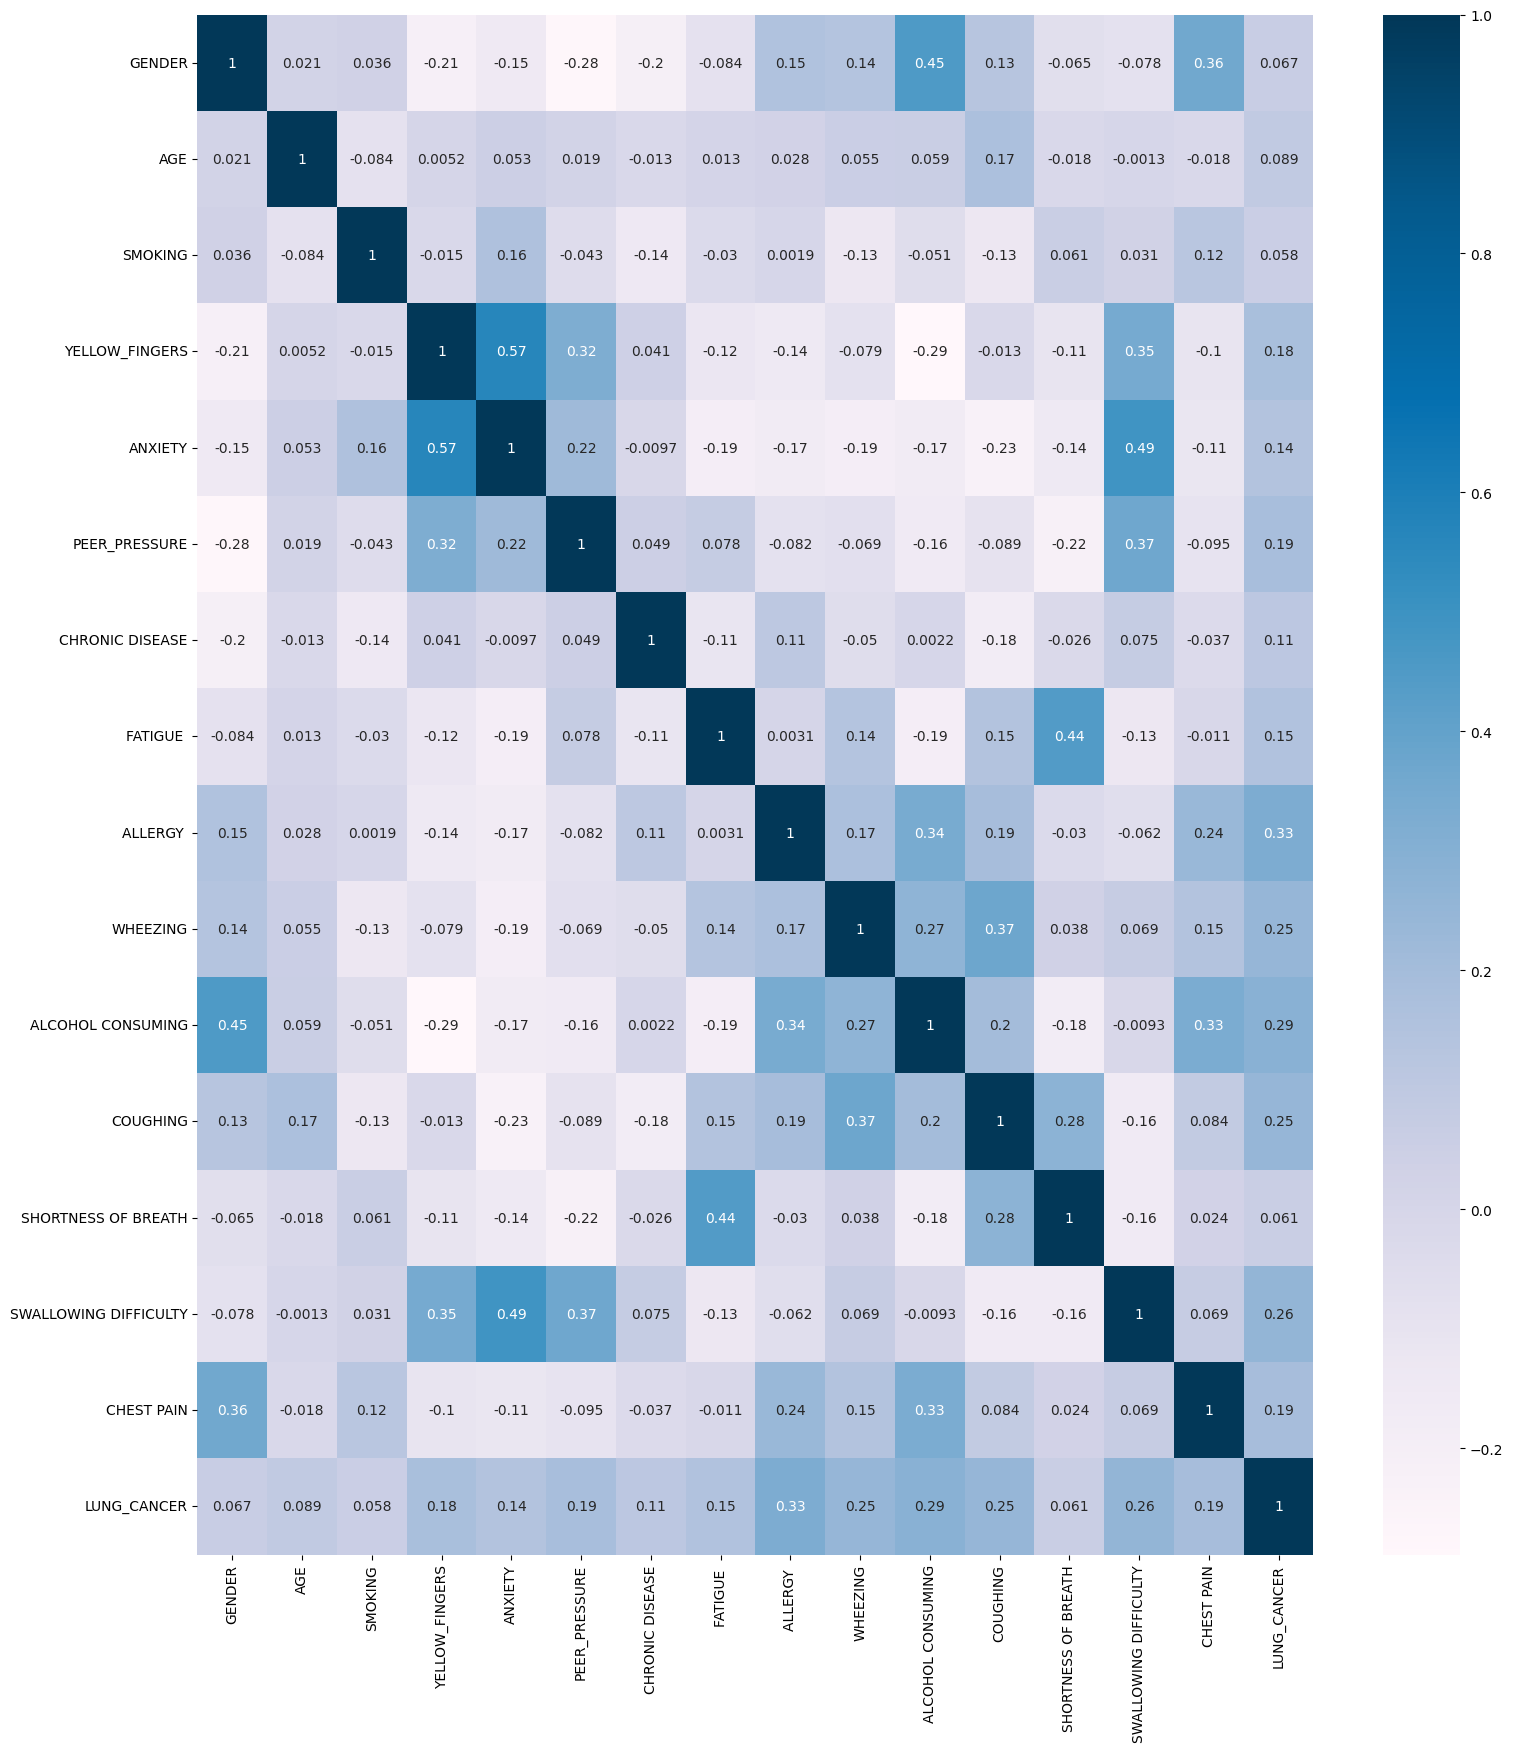

In [267]:
plt.figure(figsize=(18,20))
dataplot = sns.heatmap(df1.corr(), cmap="PuBu", annot=True)
plt.show()

In [268]:
df1.rename(columns={'LUNG_CANCER': 'TARGET'}, inplace=True)

In [269]:
df1["TARGET"].describe()

count    309.000000
mean       0.873786
std        0.332629
min        0.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: TARGET, dtype: float64

In [270]:
df1.TARGET.value_counts() / len(df1) * 100

TARGET
1    87.378641
0    12.621359
Name: count, dtype: float64

In [271]:
# Duplicate Values

df1.TARGET.value_counts() 

TARGET
1    270
0     39
Name: count, dtype: int64

<Axes: ylabel='count'>

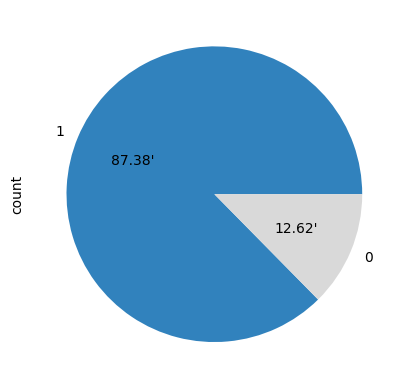

In [272]:
df1["TARGET"].value_counts().plot(kind="pie", autopct ="%.2f'", cmap= 'tab20c')

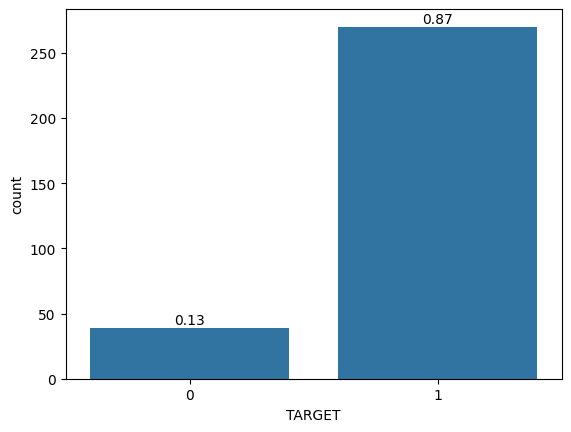

In [273]:
total = float(len(df1)) # one person per row

ax = sns.countplot(x = "TARGET", data = df1)        
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.2f}'.format(height/total),
            ha="center")

In [274]:
df1.duplicated().sum()

33

In [275]:
df1.drop('GENDER', axis=1 , inplace=True)
df1.shape

(309, 15)

In [276]:
df1.drop('AGE', axis=1 , inplace=True)
df1.shape

(309, 14)

In [277]:
cor_target = df1.corrwith(df1["TARGET"])

cor_target

SMOKING                  0.058179
YELLOW_FINGERS           0.181339
ANXIETY                  0.144947
PEER_PRESSURE            0.186388
CHRONIC DISEASE          0.110891
FATIGUE                  0.150673
ALLERGY                  0.327766
WHEEZING                 0.249300
ALCOHOL CONSUMING        0.288533
COUGHING                 0.248570
SHORTNESS OF BREATH      0.060738
SWALLOWING DIFFICULTY    0.259730
CHEST PAIN               0.190451
TARGET                   1.000000
dtype: float64

In [278]:
cor_target.sort_values(axis = 0, ascending = False)

TARGET                   1.000000
ALLERGY                  0.327766
ALCOHOL CONSUMING        0.288533
SWALLOWING DIFFICULTY    0.259730
WHEEZING                 0.249300
COUGHING                 0.248570
CHEST PAIN               0.190451
PEER_PRESSURE            0.186388
YELLOW_FINGERS           0.181339
FATIGUE                  0.150673
ANXIETY                  0.144947
CHRONIC DISEASE          0.110891
SHORTNESS OF BREATH      0.060738
SMOKING                  0.058179
dtype: float64

In [279]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   SMOKING                309 non-null    int64
 1   YELLOW_FINGERS         309 non-null    int64
 2   ANXIETY                309 non-null    int64
 3   PEER_PRESSURE          309 non-null    int64
 4   CHRONIC DISEASE        309 non-null    int64
 5   FATIGUE                309 non-null    int64
 6   ALLERGY                309 non-null    int64
 7   WHEEZING               309 non-null    int64
 8   ALCOHOL CONSUMING      309 non-null    int64
 9   COUGHING               309 non-null    int64
 10  SHORTNESS OF BREATH    309 non-null    int64
 11  SWALLOWING DIFFICULTY  309 non-null    int64
 12  CHEST PAIN             309 non-null    int64
 13  TARGET                 309 non-null    int32
dtypes: int32(1), int64(13)
memory usage: 32.7 KB


In [280]:
# Duplicate Values

df1.duplicated().sum()

176

In [281]:
df1=df1.drop_duplicates()
df1.duplicated().sum()

0

In [282]:
df1

,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,TARGET
0,1,2,2,1,1,2,1,2,2,2,2,2,2,1
1,2,1,1,1,2,2,2,1,1,1,2,2,2,1
2,1,1,1,2,1,2,1,2,1,2,2,1,2,0
3,2,2,2,1,1,1,1,1,2,1,1,2,2,0
4,1,2,1,1,1,1,1,2,1,2,2,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242,2,2,2,1,2,1,2,2,1,1,1,2,2,1
243,1,1,2,1,2,2,1,2,2,2,2,2,1,1
245,1,1,1,2,1,2,1,2,1,1,2,1,2,0
252,1,2,2,2,2,1,2,1,2,1,1,2,2,1


In [283]:

# Assuming 'your_dataframe' is your DataFrame
df1 = df1.sample(frac=1, random_state=42)
df5 = df1.sample(n=133, random_state=42)
# Reset the index of the shuffled DataFrame
df5.reset_index(drop=True, inplace=True)
df5

,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,TARGET
0,2,1,1,1,2,2,1,1,1,1,2,1,1,1
1,2,2,2,2,2,1,1,1,1,1,1,1,1,1
2,2,2,2,1,2,2,2,2,2,2,2,1,1,1
3,2,1,1,1,2,2,2,1,1,1,2,1,1,0
4,1,2,2,2,2,2,2,1,1,2,2,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,2,1,1,2,1,1,1,1,1,1,1,1,2,0
129,2,1,1,1,1,1,2,2,2,2,1,1,2,1
130,2,2,2,2,1,2,1,2,1,2,2,2,1,1
131,1,1,2,1,1,2,1,2,2,2,2,2,1,1


In [284]:
print(df5.TARGET.value_counts())

TARGET
1    109
0     24
Name: count, dtype: int64


<Axes: ylabel='count'>

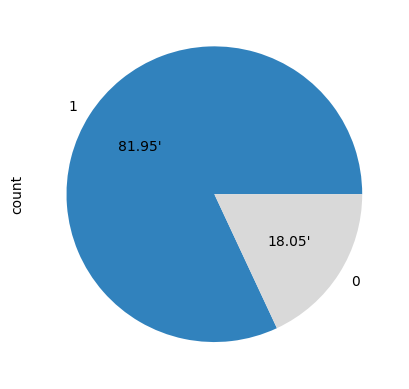

In [285]:
df5["TARGET"].value_counts().plot(kind="pie", autopct ="%.2f'", cmap= 'tab20c')

In [286]:
df6=df5.copy()

In [287]:
# Segregating Target Variable from Predictors

df_x = df5.drop(labels = ["TARGET"], axis = 1) 
df_y = df5[["TARGET"]]

In [288]:
# Train Isolation Forest model
isolation_forest = IForest(contamination=0.2, random_state=42)  # Adjust contamination as needed
isolation_forest.fit(df_x)

# Predict outliers
outlier_preds = isolation_forest.predict(df_x)

# Identify inliers (samples with label 1)
inliers_mask = outlier_preds == 0
X_inliers = df_x[inliers_mask]


df_y = df5[["TARGET"]] 
y_inliers = df_y[inliers_mask]

In [289]:
outlier_preds

array([0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0])

In [290]:
inliers_mask

array([ True,  True,  True,  True,  True, False, False,  True,  True,
        True,  True,  True,  True,  True, False,  True,  True, False,
        True,  True,  True,  True,  True, False, False,  True,  True,
        True,  True,  True,  True,  True, False,  True,  True,  True,
        True,  True,  True,  True,  True, False,  True,  True,  True,
        True,  True,  True,  True,  True, False, False, False,  True,
        True,  True,  True, False, False, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True, False,  True,  True, False,
        True,  True,  True, False, False, False,  True,  True,  True,
        True,  True, False, False,  True,  True,  True,  True, False,
       False,  True,  True,  True,  True,  True,  True,  True,  True,
       False,  True,  True, False,  True,  True,  True,  True,  True,
        True,  True, False,  True,  True,  True,  True, False,  True,
        True,  True,

In [291]:
X_inliers

,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN
0,2,1,1,1,2,2,1,1,1,1,2,1,1
1,2,2,2,2,2,1,1,1,1,1,1,1,1
2,2,2,2,1,2,2,2,2,2,2,2,1,1
3,2,1,1,1,2,2,2,1,1,1,2,1,1
4,1,2,2,2,2,2,2,1,1,2,2,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,2,1,1,2,1,1,1,1,1,1,1,1,2
129,2,1,1,1,1,1,2,2,2,2,1,1,2
130,2,2,2,2,1,2,1,2,1,2,2,2,1
131,1,1,2,1,1,2,1,2,2,2,2,2,1


In [292]:
X_inliers.reset_index(drop=True, inplace=True)
y_inliers.reset_index(drop=True, inplace=True)

In [293]:
# Split data into features and target variable
df_x = X_inliers.copy()
y = y_inliers.copy()

# Feature scaling
scaler = StandardScaler()
X1 = scaler.fit_transform(df_x)

dfx=pd.DataFrame(X1,columns=df_x.columns)

In [294]:
# Split data into training and testing sets
X_train_scaled , X_test_scaled , y_train, y_test = train_test_split(dfx, y, test_size=0.2, random_state=42)

In [295]:
df_y

,TARGET
0,1
1,1
2,1
3,0
4,1
...,...
128,0
129,1
130,1
131,1


In [296]:
from imblearn.combine import SMOTEENN
smote = SMOTEENN()
df_x_resampled,df_y_resampled = smote.fit_resample(df_x,y)

In [297]:
print(df_x.shape)
print(df_y.shape)

(106, 13)
(133, 1)


In [298]:
print(df_x.shape)
print(y.shape)

(106, 13)
(106, 1)


In [299]:
df_x_resampled.shape

(122, 13)

In [300]:
df_y_resampled.shape

(122, 1)

In [301]:
df_y_resampled.value_counts()

TARGET
0         64
1         58
Name: count, dtype: int64

In [302]:
X_train_scaled.reset_index(drop=True, inplace=True)
X_test_scaled.reset_index(drop=True, inplace=True)
y_train.reset_index(drop=True, inplace=True)
y_test.reset_index(drop=True, inplace=True)

In [303]:
# Recursive Feature Elimination (RFE) with RandomForestClassifier
def rfe_feature_selection(X_train, X_test, y_train):
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    best_accuracy = 0
    best_num_features = 0
    best_selected_features=[]
    # Iterate over different numbers of features
    for num_features in range(1, X_train.shape[1] + 1):
        # Initialize RFE
        rfe = RFE(estimator=rf, n_features_to_select=num_features, step=1)
    
        # Fit RFE
        rfe.fit(X_train, y_train)
        
        # Get selected features
        selected_features = X_train.columns[rfe.support_]
    
        # Transform datasets
        X_train_rfe = rfe.transform(X_train)
        X_test_rfe = rfe.transform(X_test)
    
        # Train RandomForestClassifier with selected features
        rf.fit(X_train_rfe, y_train)
    
        # Predict
        y_pred = rf.predict(X_test_rfe)
    
        # Calculate accuracy
        accuracy = accuracy_score(y_test, y_pred)
    
        # Update best accuracy and number of features if current accuracy is higher
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_num_features = num_features
            best_selected_features = selected_features


    print("Best number of features:", best_num_features)
    print("Best selected features:", best_selected_features)
    print("Highest accuracy:", best_accuracy)
    return X_train_rfe, X_test_rfe, best_selected_features

In [304]:
# Forward Feature Selection
def forward_feature_selection(X_train, X_test, y_train, model):
    selected_features = []
    best_accuracy = 0
    while len(selected_features) < X_train.shape[1]:
        for feature in X_train.columns:
            if feature not in selected_features:
                temp_features = selected_features + [feature]
                model.fit(X_train[temp_features], y_train)
                accuracy = model.score(X_test[temp_features], y_test)
                if accuracy > best_accuracy:
                    best_accuracy = accuracy
                    best_feature = feature
        selected_features.append(best_feature)
    print("Best selected features:", selected_features)
    print("Best accuracy:", best_accuracy)
    return X_train[selected_features], X_test[selected_features], selected_features

In [305]:
# Forward Feature Selection
def forward_feature_selection11(X_train, X_test, y_train, y_test, model):
    selected_features = []
    best_accuracy = 0
    while len(selected_features) < X_train.shape[1]:
        best_accuracy_for_iteration = 0
        best_feature_for_iteration = None
        for feature in X_train.columns:
            if feature not in selected_features:
                temp_features = selected_features + [feature]
                model.fit(X_train[temp_features], y_train)
                accuracy = model.score(X_test[temp_features], y_test)
                if accuracy > best_accuracy_for_iteration:
                    best_accuracy_for_iteration = accuracy
                    best_feature_for_iteration = feature
        selected_features.append(best_feature_for_iteration)
        if best_accuracy_for_iteration > best_accuracy:
            best_accuracy = best_accuracy_for_iteration
    print("Best selected features:", selected_features)
    print("Best accuracy:", best_accuracy)
    return X_train[selected_features], X_test[selected_features], selected_features


In [306]:
# Backward Feature Selection
def backward_feature_selection(X_train, X_test, y_train, model):
    selected_features = list(X_train.columns)
    best_accuracy = model.fit(X_train, y_train).score(X_test, y_test)  # Initial accuracy with all features
    while len(selected_features) > 0:
        best_feature = None
        for feature in selected_features:
            temp_features = selected_features.copy()
            temp_features.remove(feature)
            accuracy = model.fit(X_train[temp_features], y_train).score(X_test[temp_features], y_test)
            if accuracy >= best_accuracy:  # Adjusted condition
                best_accuracy = accuracy
                best_feature = feature
        if best_feature is not None:
            selected_features.remove(best_feature)
        else:
            break  # Exit the loop if no improvement is found
    print("Best selected features:", selected_features)
    print("Best accuracy:", best_accuracy)
    return X_train[selected_features], X_test[selected_features], selected_features

In [307]:
# ANOVA F-value
def anova_f_value_selection11(X_train, X_test, y_train, y_test, k):
    skb = SelectKBest(score_func=f_classif, k=k)
    X_train_skb = skb.fit_transform(X_train, y_train)
    X_test_skb = skb.transform(X_test)
    return X_train_skb, X_test_skb, skb.get_support()

In [308]:
# Pearson Correlation
def pearson_correlation_selection(X_train, X_test, threshold):
    corr_matrix = X_train.corr()
    corr_features = set()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]
                corr_features.add(colname)
    X_train_corr = X_train.drop(labels=corr_features, axis=1)
    X_test_corr = X_test.drop(labels=corr_features, axis=1)
    return X_train_corr, X_test_corr

In [309]:
def lasso_regression_feature_selection(X_train, X_test, y_train, y_test, alpha):
    # Initialize Lasso regression model
    lasso = Lasso(alpha=alpha, random_state=42)
    
    # Fit Lasso regression on training data
    lasso.fit(X_train, y_train)
    
    # Get coefficients and select features with non-zero coefficients
    selected_features = X_train.columns[lasso.coef_ != 0]
    
    # Train RandomForestClassifier with selected features
    rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_classifier.fit(X_train[selected_features], y_train)
    
    # Predict
    y_pred = rf_classifier.predict(X_test[selected_features])
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    
    print("Selected features with Lasso regression:", selected_features)
    #print("Accuracy with selected features:", accuracy)
    
    return X_train[selected_features], X_test[selected_features], selected_features


In [310]:
np.int = np.int32
np.float = np.float64
np.bool = np.bool_

In [311]:
# Boruta method
def boruta_feature_selection(X_train, X_test, y_train, y_test):
    # Initialize BorutaPy object with RandomForestClassifier estimator
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    boruta_selector = BorutaPy(rf, n_estimators='auto', random_state=42)
    
    # Fit Boruta on training data
    boruta_selector.fit(X_train.values, y_train.values)
    
    # Get selected features
    selected_features = X_train.columns[boruta_selector.support_].tolist()
    
    # Train a model using selected features
    rf_selected = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_selected.fit(X_train[selected_features], y_train)
    
    # Predict on testing data
    y_pred = rf_selected.predict(X_test[selected_features])
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    
    #print("Selected features with Boruta:", selected_features)
    #print("Accuracy with selected features:", accuracy)
    
    return X_train[selected_features], X_test[selected_features], selected_features

In [312]:
# Apply feature selection methods
X_train_rfe, X_test_rfe, rfe_fs = rfe_feature_selection(X_train_scaled, X_test_scaled, y_train)
X_train_forward, X_test_forward, forward_fs = forward_feature_selection11(X_train_scaled, X_test_scaled, y_train, y_test, RandomForestClassifier())
X_train_backward, X_test_backward, backward_fs = backward_feature_selection(X_train_scaled, X_test_scaled, y_train, RandomForestClassifier())
X_train_lasso, X_test_lasso, lasso_fs = lasso_regression_feature_selection(X_train_scaled, X_test_scaled, y_train, y_test, alpha=0.01)
X_train_boruta, X_test_boruta, boruta_fs =boruta_feature_selection(X_train_scaled, X_test_scaled, y_train, y_test)




Best number of features: 3
Best selected features: Index(['ANXIETY', 'CHRONIC DISEASE', 'ALCOHOL CONSUMING'], dtype='object')
Highest accuracy: 0.8181818181818182
Best selected features: ['SMOKING', 'YELLOW_FINGERS', 'ANXIETY', 'CHRONIC DISEASE', 'FATIGUE ', 'PEER_PRESSURE', 'WHEEZING', 'ALCOHOL CONSUMING', 'COUGHING', 'ALLERGY ', 'SHORTNESS OF BREATH', 'SWALLOWING DIFFICULTY', 'CHEST PAIN']
Best accuracy: 0.8636363636363636
Best selected features: ['CHRONIC DISEASE', 'FATIGUE ', 'ALCOHOL CONSUMING']
Best accuracy: 0.9090909090909091
Selected features with Lasso regression: Index(['SMOKING', 'ANXIETY', 'PEER_PRESSURE', 'CHRONIC DISEASE', 'FATIGUE ',
       'ALLERGY ', 'WHEEZING', 'ALCOHOL CONSUMING', 'COUGHING',
       'SWALLOWING DIFFICULTY', 'CHEST PAIN'],
      dtype='object')


In [313]:
# Initialize RandomForestClassifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

best_accuracy = 0
best_selected_features = []

# Iterate over different numbers of features
for num_features in range(1, X_train_scaled.shape[1] + 1):
    # Apply ANOVA F-value selection
    X_train_skb, X_test_skb, selected_features = anova_f_value_selection11(X_train_scaled, X_test_scaled, y_train, y_test, num_features)
    
    # Train RandomForestClassifier with selected features
    rf_classifier.fit(X_train_skb, y_train)
    
    # Predict
    y_pred = rf_classifier.predict(X_test_skb)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    
    # Update best accuracy and selected features if current accuracy is higher
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_selected_features = selected_features

print("Features with highest accuracy:", best_selected_features)
#print("Highest accuracy:", best_accuracy)

df_selected = X_train_scaled.loc[:, best_selected_features]
print(df_selected.columns)
anv_fs=df_selected.columns
X_train_skb, X_test_skb=X_train_scaled[df_selected.columns],X_test_scaled[df_selected.columns]

Features with highest accuracy: [False False  True False  True False  True False  True False False  True
 False]
Index(['ANXIETY', 'CHRONIC DISEASE', 'ALLERGY ', 'ALCOHOL CONSUMING',
       'SWALLOWING DIFFICULTY'],
      dtype='object')


In [314]:
X_train_corr, X_test_corr = pearson_correlation_selection(X_train_scaled, X_test_scaled, threshold=0.5)
pcorr_fs=X_train_corr.columns

In [315]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error

lr_train_mae = mean_absolute_error(y_train, lr_train_preds)
lr_test_mae = mean_absolute_error(y_test, lr_test_preds)

result = permutation_importance(lr, X_train_scaled, y_train, n_repeats=3)
lr_fi = result.importances_mean

print(lr_fi)

[6.45768762e-03 9.19038819e-04 2.69946316e-01 1.51771908e-02
 1.44370657e-01 1.10411583e-01 7.48296804e-03 8.07999593e-03
 1.37424491e-01 9.21239823e-02 2.21592363e-04 1.70007988e-02
 1.90106995e-02]


In [316]:
# Sort feature importances in descending order
sorted_indices = np.argsort(lr_fi)[::-1]

# Get the names of features corresponding to the sorted importances
sorted_features = X_train_scaled.columns[sorted_indices]

# Get the top 5 features
lr_features = sorted_features[:7]

print("Top 7 features:", lr_features)

Top 7 features: Index(['ANXIETY', 'CHRONIC DISEASE', 'ALCOHOL CONSUMING', 'FATIGUE ',
       'COUGHING', 'CHEST PAIN', 'SWALLOWING DIFFICULTY'],
      dtype='object')


In [317]:
# KNN
knn = KNeighborsRegressor(n_neighbors=int(np.sqrt(len(X_train_scaled))))
knn.fit(X_train_scaled, y_train)

knn_train_preds = knn.predict(X_train_scaled)
knn_test_preds = knn.predict(X_test_scaled)

knn_train_mae = mean_absolute_error(y_train, knn_train_preds)
knn_test_mae = mean_absolute_error(y_test, knn_test_preds)

from sklearn.inspection import permutation_importance

result = permutation_importance(knn, X_train_scaled, y_train, n_repeats=3)
knn_fi = result.importances_mean

print(knn_fi)

[ 0.01112019  0.00921387  0.07498184  0.00698983  0.06608569 -0.00190632
  0.01525054  0.01874546  0.09023239  0.03431373 -0.02033406  0.04765795
  0.00698983]


In [318]:
# Sort feature importances in descending order
sorted_indices = np.argsort(knn_fi)[::-1]

# Get the names of features corresponding to the sorted importances
sorted_features = X_train_scaled.columns[sorted_indices]

# Get the top 5 features
knn_features = sorted_features[:7]

print("Top 7 features:", knn_features)

Top 7 features: Index(['ALCOHOL CONSUMING', 'ANXIETY', 'CHRONIC DISEASE',
       'SWALLOWING DIFFICULTY', 'COUGHING', 'WHEEZING', 'ALLERGY '],
      dtype='object')


In [319]:
# Support Vector Regression
svr = SVR(C=.1)
svr.fit(X_train_scaled, y_train)

svr_train_preds = svr.predict(X_train_scaled)
svr_test_preds = svr.predict(X_test_scaled)

svr_train_mae = mean_absolute_error(y_train, svr_train_preds)
svr_test_mae = mean_absolute_error(y_test, svr_test_preds)

from sklearn.inspection import permutation_importance

result = permutation_importance(svr, X_train_scaled, y_train, n_repeats=3)
svr_fi = result.importances_mean

print(svr_fi)

[0.01344095 0.01444775 0.04128721 0.01838783 0.02990679 0.02748434
 0.02377913 0.02926105 0.03470978 0.02731626 0.01719023 0.02512209
 0.00908369]


In [320]:
# Sort feature importances in descending order
sorted_indices = np.argsort(svr_fi)[::-1]

# Get the names of features corresponding to the sorted importances
sorted_features = X_train_scaled.columns[sorted_indices]

# Get the top 5 features
svm_features = sorted_features[:7]

print("Top 7 features:", svm_features)

Top 7 features: Index(['ANXIETY', 'ALCOHOL CONSUMING', 'CHRONIC DISEASE', 'WHEEZING',
       'FATIGUE ', 'COUGHING', 'SWALLOWING DIFFICULTY'],
      dtype='object')


In [321]:
# Random Forest
rf = RandomForestRegressor(max_depth=7)
rf.fit(X_train_scaled, y_train)

rf_train_preds = rf.predict(X_train_scaled)
rf_test_preds = rf.predict(X_test_scaled)

rf_train_mae = mean_absolute_error(y_train, rf_train_preds)
rf_test_mae = mean_absolute_error(y_test, rf_test_preds)

rf_fi = rf.feature_importances_
rf_fi

array([0.06576823, 0.06301739, 0.18470918, 0.05599897, 0.10101607,
       0.07386927, 0.08172468, 0.05046461, 0.10885662, 0.06336844,
       0.05838027, 0.05106354, 0.04176274])

In [322]:
# Sort feature importances in descending order
sorted_indices = np.argsort(rf_fi)[::-1]

# Get the names of features corresponding to the sorted importances
sorted_features = X_train_scaled.columns[sorted_indices]

# Get the top 5 features
rf_features = sorted_features[:7]

print("Top 7 features:", rf_features)

Top 7 features: Index(['ANXIETY', 'ALCOHOL CONSUMING', 'CHRONIC DISEASE', 'ALLERGY ',
       'FATIGUE ', 'SMOKING', 'COUGHING'],
      dtype='object')


In [323]:
# XGBOOST
xgb = XGBRegressor(max_depth=7)
xgb.fit(X_train_scaled, y_train)

xgb_train_preds = xgb.predict(X_train_scaled)
xgb_test_preds = xgb.predict(X_test_scaled)

xgb_train_mae = mean_absolute_error(y_train, xgb_train_preds)
xgb_test_mae = mean_absolute_error(y_test, xgb_test_preds)

xgb_fi = xgb.feature_importances_
xgb_fi

array([0.05304694, 0.03339393, 0.11752864, 0.04412568, 0.11238456,
       0.03533343, 0.00517132, 0.06413455, 0.21614468, 0.10910001,
       0.03967476, 0.1414568 , 0.0285048 ], dtype=float32)

In [324]:
# Sort feature importances in descending order
sorted_indices = np.argsort(xgb_fi)[::-1]

# Get the names of features corresponding to the sorted importances
sorted_features = X_train_scaled.columns[sorted_indices]

# Get the top 5 features
xgb_features = sorted_features[:7]

print("Top 7 features:", xgb_features)

Top 7 features: Index(['ALCOHOL CONSUMING', 'SWALLOWING DIFFICULTY', 'ANXIETY',
       'CHRONIC DISEASE', 'COUGHING', 'WHEEZING', 'SMOKING'],
      dtype='object')


In [325]:
# Light GBM
lgb = LGBMRegressor(max_depth=7)
lgb.fit(X_train_scaled, y_train)

lgb_train_preds = lgb.predict(X_train_scaled)
lgb_test_preds = lgb.predict(X_test_scaled)

lgb_train_mae = mean_absolute_error(y_train, lgb_train_preds)
lgb_test_mae = mean_absolute_error(y_test, lgb_test_preds)

lgb_fi = lgb.feature_importances_
lgb_fi

array([ 0, 14, 31, 23, 49, 22,  8, 16, 25, 18,  0,  5,  7])

In [326]:
# Sort feature importances in descending order
sorted_indices = np.argsort(lgb_fi)[::-1]

# Get the names of features corresponding to the sorted importances
sorted_features = X_train_scaled.columns[sorted_indices]

# Get the top 5 features
lgb_features = sorted_features[:7]

print("Top 7 features:", lgb_features)

Top 7 features: Index(['CHRONIC DISEASE', 'ANXIETY', 'ALCOHOL CONSUMING', 'PEER_PRESSURE',
       'FATIGUE ', 'COUGHING', 'WHEEZING'],
      dtype='object')


In [327]:
# create a dataframe for feature importances and mean absolute error
mae_df = pd.DataFrame(columns=['Train','Test'])

# add mae's to the mae_df
mae_df.loc['Linear Regression','Train'] =  lr_train_mae
mae_df.loc['Linear Regression','Test'] =  lr_test_mae

mae_df.loc['KNN','Train'] =  knn_train_mae
mae_df.loc['KNN','Test'] =  knn_test_mae

mae_df.loc['Support Vector Regression','Train'] =  svr_train_mae
mae_df.loc['Support Vector Regression','Test'] =  svr_test_mae

mae_df.loc['Random Forest','Train'] =  rf_train_mae
mae_df.loc['Random Forest','Test'] =  rf_test_mae

mae_df.loc['XGBoost','Train'] =  xgb_train_mae
mae_df.loc['XGBoost','Test'] =  xgb_test_mae

mae_df.loc['Light GBM','Train'] =  lgb_train_mae
mae_df.loc['Light GBM','Test'] =  lgb_test_mae

mae_df['Model'] = mae_df.index
mae_df['Train'] = mae_df['Train'].astype(float)
mae_df['Test'] = mae_df['Test'].astype(float)

mae_df = pd.melt(mae_df, id_vars=['Model'], value_vars=['Train','Test'])

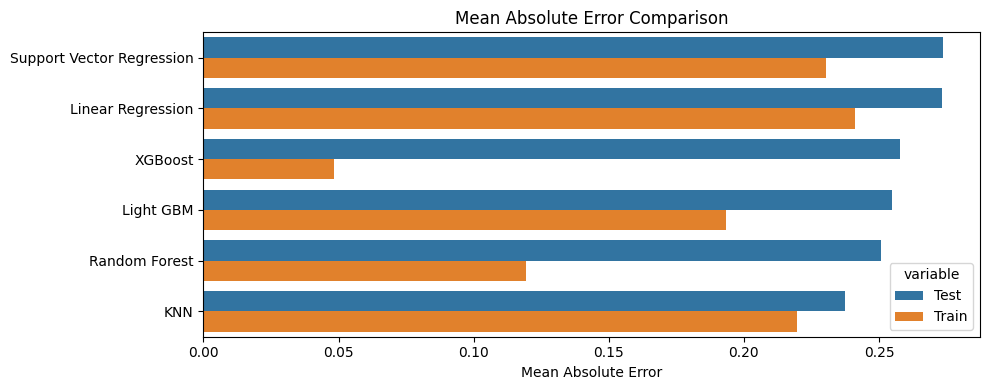

In [328]:
# plot mae
fig,ax = plt.subplots(figsize=(10,4))
ax = sns.barplot(x='value',y='Model', hue='variable',data=mae_df.sort_values(by='value',ascending=False))
plt.xlabel('Mean Absolute Error')
plt.ylabel('')
plt.title('Mean Absolute Error Comparison')
plt.tight_layout()

In [329]:
# create feature importance dataframe
fi_df = pd.DataFrame(columns=['LR', 'KNN','SVR','RF','XGB','LGBM','Features'])
#feature_names =    ["a", "b", "c", "d","e", "f", "g", "h","i", "j", "k", "l","m", "n", "o"]

fi_df['Features'] = dfx.columns
fi_df['LR'] = lr_fi
fi_df['KNN'] = knn_fi
fi_df['SVR'] = svr_fi
fi_df['RF'] = rf_fi
fi_df['XGB'] = xgb_fi
fi_df['LGBM'] = lgb_fi/1000

In [330]:
fi_df

,LR,KNN,SVR,RF,XGB,LGBM,Features
0,0.006458,0.011120,0.013441,0.065768,0.053047,0.000,SMOKING
1,0.000919,0.009214,0.014448,0.063017,0.033394,0.014,YELLOW_FINGERS
2,0.269946,0.074982,0.041287,0.184709,0.117529,0.031,ANXIETY
3,0.015177,0.006990,0.018388,0.055999,0.044126,0.023,PEER_PRESSURE
4,0.144371,0.066086,0.029907,0.101016,0.112385,0.049,CHRONIC DISEASE
5,0.110412,-0.001906,0.027484,0.073869,0.035333,0.022,FATIGUE
6,0.007483,0.015251,0.023779,0.081725,0.005171,0.008,ALLERGY
7,0.008080,0.018745,0.029261,0.050465,0.064135,0.016,WHEEZING
8,0.137424,0.090232,0.034710,0.108857,0.216145,0.025,ALCOHOL CONSUMING
9,0.092124,0.034314,0.027316,0.063368,0.109100,0.018,COUGHING


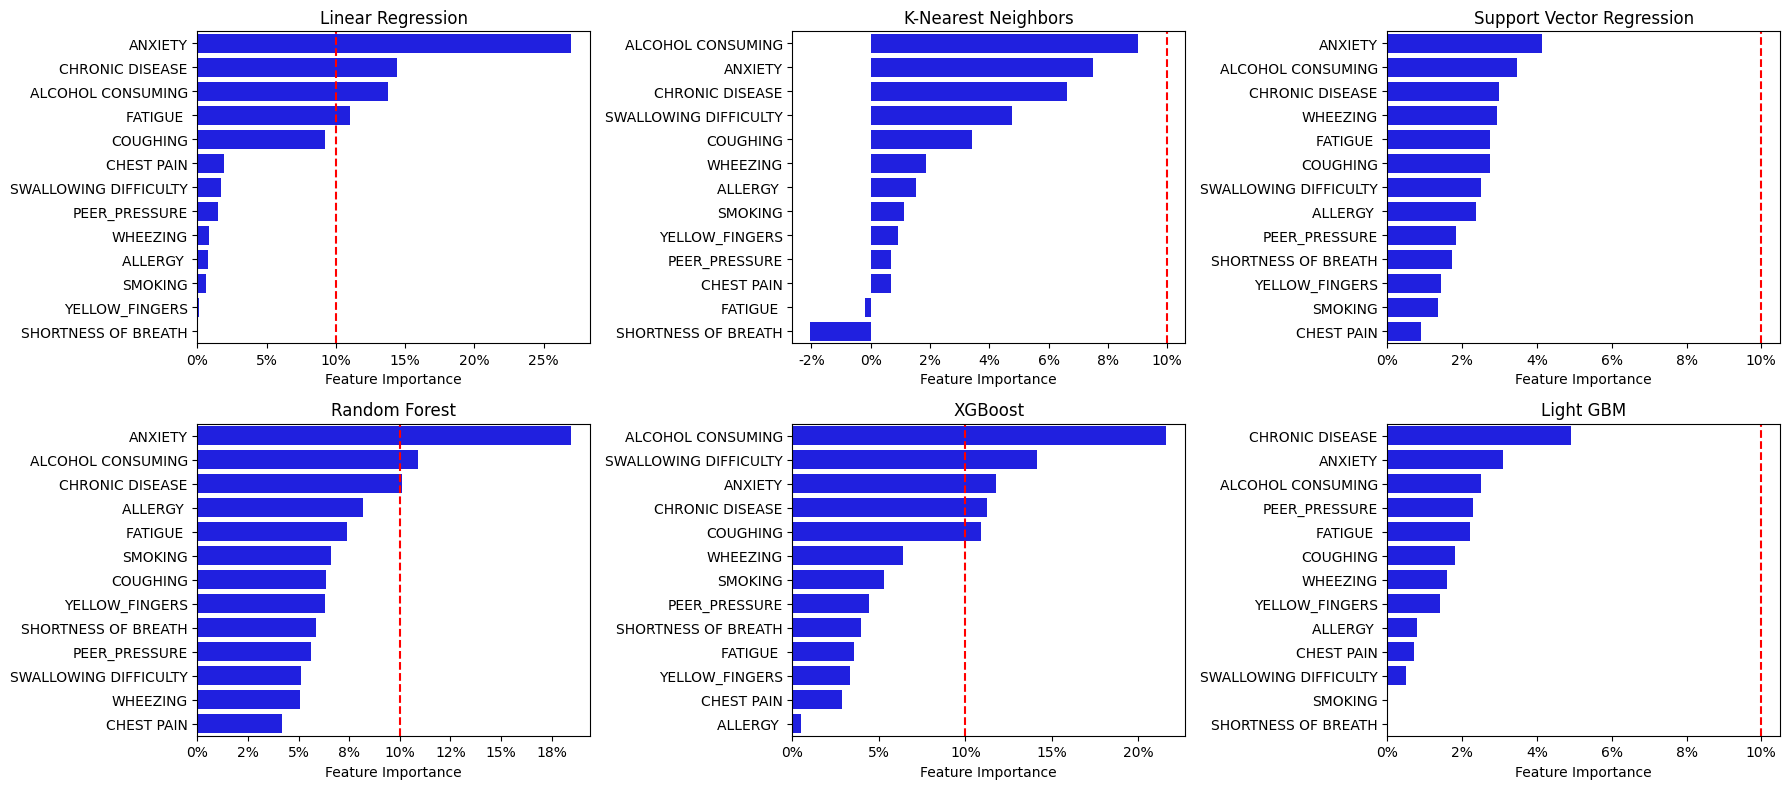

In [331]:
fig = plt.figure(figsize=(18,8))

plt.subplot(2, 3, 1)
ax = sns.barplot(x='LR',y='Features',data=fi_df.sort_values(by='LR',ascending=False),color='b')
ax.xaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
plt.xlabel('Feature Importance')
plt.ylabel('')
plt.title('Linear Regression')
plt.axvline(x=0.1, color='r', linestyle='dashed')
plt.tight_layout()

plt.subplot(2, 3, 2)
ax = sns.barplot(x='KNN',y='Features',data=fi_df.sort_values(by='KNN',ascending=False),color='b')
ax.xaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
plt.xlabel('Feature Importance')
plt.ylabel('')
plt.title('K-Nearest Neighbors')
plt.axvline(x=0.1, color='r', linestyle='dashed')
plt.tight_layout()

plt.subplot(2, 3, 3)
ax = sns.barplot(x='SVR',y='Features',data=fi_df.sort_values(by='SVR',ascending=False),color='b')
ax.xaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
plt.xlabel('Feature Importance')
plt.ylabel('')
plt.title('Support Vector Regression')
plt.axvline(x=0.1, color='r', linestyle='dashed')
plt.tight_layout()

plt.subplot(2, 3, 4)
ax = sns.barplot(x='RF',y='Features',data=fi_df.sort_values(by='RF',ascending=False),color='b')
ax.xaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
plt.xlabel('Feature Importance')
plt.ylabel('')
plt.title('Random Forest')
plt.axvline(x=0.1, color='r', linestyle='dashed')
plt.tight_layout()

plt.subplot(2, 3, 5)
ax = sns.barplot(x='XGB',y='Features',data=fi_df.sort_values(by='XGB',ascending=False),color='b')
ax.xaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
plt.xlabel('Feature Importance')
plt.ylabel('')
plt.title('XGBoost')
plt.axvline(x=0.1, color='r', linestyle='dashed')
plt.tight_layout()

plt.subplot(2, 3, 6)
ax = sns.barplot(x='LGBM',y='Features',data=fi_df.sort_values(by='LGBM',ascending=False),color='b')
ax.xaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
plt.xlabel('Feature Importance')
plt.ylabel('')
plt.title('Light GBM')
plt.axvline(x=0.1, color='r', linestyle='dashed')
plt.tight_layout()

In [332]:
from boruta import BorutaPy

new_rf = RandomForestRegressor(n_jobs = -1, max_depth = 5)

boruta_selector = BorutaPy(new_rf, n_estimators = 'auto', random_state = 0)
boruta_selector.fit(np.array(X_train_scaled), np.array(y_train))

boruta_ranking = boruta_selector.ranking_
boruta_features = np.array(dfx.columns)[boruta_ranking <= 3]

In [333]:
boruta_ranking = pd.DataFrame(data=boruta_ranking, index=X_train_scaled.columns.values, columns=['values'])
boruta_ranking['Variable'] = boruta_ranking.index
boruta_ranking.sort_values(['values'], ascending=True, inplace=True)

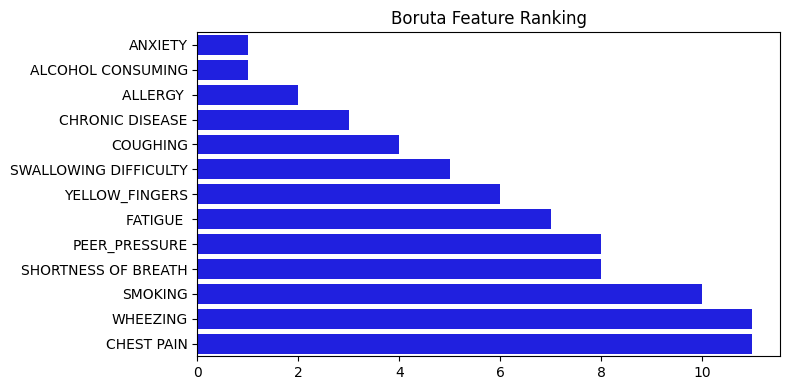

In [334]:
fig,ax = plt.subplots(figsize=(8,4))
ax = sns.barplot(x='values',y='Variable',data=boruta_ranking, color='b')
plt.title('Boruta Feature Ranking')
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()

In [335]:
feature_names =dfx.columns

In [336]:
# Convert array to list
feature_list = boruta_features.tolist()
#feature_list

In [337]:
from collections import Counter

# Lists of features
LRf = lr_features.tolist()
KNNf= knn_features.tolist()
SVRf= svm_features.tolist()
RFf= rf_features.tolist()
XGBf= xgb_features.tolist()
LGBMf=lgb_features.tolist()
BORf=boruta_features.tolist()

# Combine all lists
all_features = LRf + KNNf + SVRf + RFf + XGBf + LGBMf + BORf
Uf=list(set().union(LRf,KNNf,SVRf,RFf,XGBf,LGBMf,BORf))
# Count occurrences of each feature
feature_counts = Counter(all_features)

# Find the features with the highest counts
majority_features = [feature for feature, count in feature_counts.items() if count > 3]  # Adjust threshold as needed
#print("All features:", Uf)
print("Majority features:", majority_features)

Majority features: ['ANXIETY', 'CHRONIC DISEASE', 'ALCOHOL CONSUMING', 'FATIGUE ', 'COUGHING', 'SWALLOWING DIFFICULTY', 'WHEEZING']


In [338]:
def evall(Xf,yf,fs,sm):
    t=0
    data=[]
    
    # Perform StratifiedKFold cross-validation
    cv = StratifiedKFold(n_splits=10)
    weights1 = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(yf),
    y=yf.values.reshape(-1))
    print("weights = ",weights1)
    a=weights1[0]
    b=weights1[1]

    lr = LogisticRegression(random_state=42, class_weight={0: a, 1: b})
    svm = SVC()
    knn = KNeighborsClassifier()
    dt = DecisionTreeClassifier()
    ab = AdaBoostClassifier()
    gb = GradientBoostingClassifier()
    lgbm = lgbb.LGBMClassifier(verbose=-1)
    cb = CatBoostClassifier(verbose=0)
    et = ExtraTreesClassifier()
    rf= RandomForestClassifier()
    xgb = XGBClassifier()
    gnb = GaussianNB()


    clff=[lr, svm, knn, dt, ab, gb, lgbm, cb, et, rf, xgb, gnb]
    cl=['lr','svm','knn','dt','ab','gb','lgbm','cb','et','rf','xgb','gnb']
    
    for clf in clff:
        accuracies4 = []
        spec4=[]
        mcc4=[]
        ck4=[]
        f14=[]
        pr4=[]
        re4=[]
        gmean4=[]
        r4=[]
        for train_index, test_index in cv.split(Xf, yf):
            X_traincv, X_testcv = Xf.iloc[train_index], Xf.iloc[test_index]
            y_traincv, y_testcv = yf.iloc[train_index], yf.iloc[test_index]
      
            clf.fit(X_traincv, y_traincv)
            y_pred1 = clf.predict(X_testcv)
            
            accuracy1 = accuracy_score(y_testcv, y_pred1)
            accuracies4.append(accuracy1)
            
            clf_report = pd.DataFrame(classification_report(y_testcv, y_pred1, output_dict=True))
            cm = confusion_matrix(y_testcv, y_pred1)
            tn = cm[0][0]
            fn = cm[1][0]
            fp = cm[0][1]
            tp = cm[1][1]
            
            sp = tn/(tn+fp)
            spec4.append(sp)
            
            Pre = precision_score(y_testcv, y_pred1)
            pr4.append(Pre)
            
            Rec=recall_score(y_testcv, y_pred1)
            re4.append(Rec)
            
            gm=mt.sqrt(sp*Rec)
            gmean4.append(gm)
            
            m=matthews_corrcoef(y_testcv, y_pred1)
            mcc4.append(m)
            
            c=cohen_kappa_score(y_testcv, y_pred1)
            ck4.append(c)
            
            f=f1_score(y_testcv, y_pred1)
            f14.append(f)
            
            roc=roc_auc_score(y_testcv, y_pred1)
            r4.append(roc)
            
        average_accuracy4 = sum(accuracies4) / len(accuracies4)
        average_specificity4 = sum(spec4) / len(spec4)
        average_mcc4 = sum(mcc4) / len(mcc4)
        average_ck4 = sum(ck4) / len(ck4)
        average_f14 = sum(f14) / len(f14)
        average_Precision4 = sum(pr4) / len(pr4)
        average_Recall4 = sum(re4) / len(re4)
        average_gmean4 = sum(gmean4) / len(gmean4)
        average_roc4 = sum(r4) / len(r4)

        #data.append((clff[t],f"{average_accuracy4:{w}.{pre}}",f"{average_specificity4:{w}.{pre}}",f"{average_mcc4:{w}.{pre}}",f"{average_ck4:{w}.{pre}}",f"{average_f14:{w}.{pre}}",f"{average_Precision4:{w}.{pre}}",f"{average_Recall4:{w}.{pre}}",f"{average_gmean4:{w}.{pre}}",f"{average_roc4:{w}.{pre}}"))
        data.append((fs,sm,cl[t],average_accuracy4,average_specificity4,average_mcc4,average_ck4,average_f14,average_Precision4,average_Recall4,average_gmean4,average_roc4))

        t=t+1
    return data

In [339]:
def favg(df):
    selected_columns = ['Accuracy','Specificity','MCC','CK','F1-Score','Precision','Recall','Gmean','roc_Score']
    row_averages = df[selected_columns].mean(axis=1)
    df['Pmean'] = row_averages
    print(df.to_string(index=False,justify='left'))
    return df

In [340]:
def evgraph(df):
    
    # Transpose the DataFrame
    selected_columns = ['Classifier','Accuracy','Specificity','MCC','CK','F1-Score','Precision','Recall','Gmean','roc_Score','Pmean']
    df1 = df[selected_columns]
    dfr_transposed = df1.set_index('Classifier').T.reset_index()
    # Plotting the multi-line graph with transposed data
    plt.figure(figsize=(8, 6))

    classifiers = dfr_transposed.columns[1:]  # Exclude the 'index' column

    for classifier in classifiers:
        plt.plot(dfr_transposed['index'], dfr_transposed[classifier], marker='o', linestyle='-', label=classifier)

    # Adding labels and title
    plt.xlabel('Metrics')
    plt.ylabel('Classifier Values')
    plt.title('Classifiers Across Metrics')
    plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better visibility

    # Adding a legend
    plt.legend()
    # Adding horizontal grid lines
    plt.grid(True, axis='y')
    # Display the plot
    plt.tight_layout()
    plt.show()

In [341]:
fdf=dfx.copy()
fdf['TARGET']=y
fdf

,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,TARGET
0,0.747545,-1.187051,-1.019049,-0.875595,0.909718,0.732279,-0.962950,-0.89253,-0.89253,-0.981307,0.762948,-0.842424,-1.187051,1
1,0.747545,0.842424,0.981307,1.142080,0.909718,-1.365601,-0.962950,-0.89253,-0.89253,-0.981307,-1.310705,-0.842424,-1.187051,1
2,0.747545,0.842424,0.981307,-0.875595,0.909718,0.732279,1.038476,1.12041,1.12041,1.019049,0.762948,-0.842424,-1.187051,1
3,0.747545,-1.187051,-1.019049,-0.875595,0.909718,0.732279,1.038476,-0.89253,-0.89253,-0.981307,0.762948,-0.842424,-1.187051,0
4,-1.337712,0.842424,0.981307,1.142080,0.909718,0.732279,1.038476,-0.89253,-0.89253,1.019049,0.762948,-0.842424,-1.187051,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,0.747545,-1.187051,-1.019049,1.142080,-1.099242,-1.365601,-0.962950,-0.89253,-0.89253,-0.981307,-1.310705,-0.842424,0.842424,0
102,0.747545,-1.187051,-1.019049,-0.875595,-1.099242,-1.365601,1.038476,1.12041,1.12041,1.019049,-1.310705,-0.842424,0.842424,1
103,0.747545,0.842424,0.981307,1.142080,-1.099242,0.732279,-0.962950,1.12041,-0.89253,1.019049,0.762948,1.187051,-1.187051,1
104,-1.337712,-1.187051,0.981307,-0.875595,-1.099242,0.732279,-0.962950,1.12041,1.12041,1.019049,0.762948,1.187051,-1.187051,1


In [342]:
RFEf=rfe_fs.tolist()
FORWf=forward_fs
BACKWf=backward_fs
ANOf=anv_fs.tolist()
PEARf=pcorr_fs.tolist()
LASSOf=lasso_fs.tolist()

In [343]:
odresult=[]
fsname=['LRf' , 'KNNf' , 'SVRf' , 'RFf', 'XGBf', 'LGBMf', 'BORf', 'RFEf', 'FORWf', 'BACKWf', 'ANOf', 'PEARf', 'LASSOf', 'Uf', 'majority_features']

lt=[LRf , KNNf , SVRf , RFf, XGBf, LGBMf, BORf, RFEf, FORWf, BACKWf, ANOf, PEARf, LASSOf, Uf, majority_features]
#lt

tin=0



weights =  [2.52380952 0.62352941]
FName  SMOTE Classifier  Accuracy  Specificity  MCC      CK       F1-Score  Precision  Recall   Gmean    roc_Score  Pmean  
LRf   0        lr       0.791818  0.800000     0.499379 0.450212 0.852796  0.956818   0.786111 0.728865 0.793056   0.739895
LRf   0       svm       0.791818  0.166667     0.119815 0.115801 0.877495  0.825732   0.940278 0.213754 0.553472   0.511648
LRf   0       knn       0.790909  0.316667     0.206592 0.203230 0.873137  0.850025   0.905556 0.365829 0.611111   0.569228
LRf   0        dt       0.752727  0.466667     0.240141 0.227091 0.839381  0.870747   0.820833 0.497043 0.643750   0.595376
LRf   0        ab       0.848182  0.466667     0.445866 0.428151 0.907987  0.882096   0.940278 0.549456 0.703472   0.685795
LRf   0        gb       0.839091  0.466667     0.431162 0.412562 0.901256  0.880588   0.929167 0.577360 0.697917   0.681752
LRf   0      lgbm       0.847273  0.416667     0.435553 0.415270 0.907987  0.870985   0.951389 0.

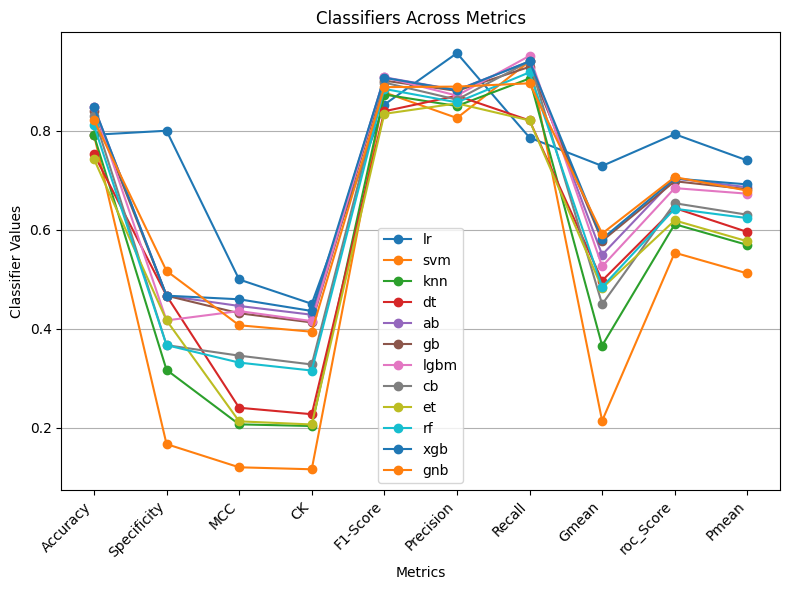

+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
weights =  [1. 1.]
FName  SMOTE Classifier  Accuracy  Specificity  MCC      CK       F1-Score  Precision  Recall   Gmean    roc_Score  Pmean  
LRf   1        lr       0.858824  0.915278     0.733859 0.714148 0.842579  0.920184   0.794444 0.846014 0.854861   0.831132
LRf   1       svm       0.888235  0.926389     0.793174 0.773913 0.883768  0.944945   0.844444 0.876854 0.885417   0.868571
LRf   1       knn       0.876471  0.952778     0.768145 0.751956 0.862178  0.950714   0.798611 0.869202 0.875694   0.856194
LRf   1        dt       0.841176  0.865278     0.701322 0.677642 0.835499  0.891056   0.806944 0.824609 0.836111   0.808849
LRf   1        ab       0.870588  0.802778     0.758623 0.735912 0.881330  0.854573   0.927778 0.852678 0.865278   0.838837
LRf   1        gb       0.894118  0.888889     0.805054 0.785630 0.898002  0.920620   0.894444 0.882702 0.891667   0.873458
LRf   1

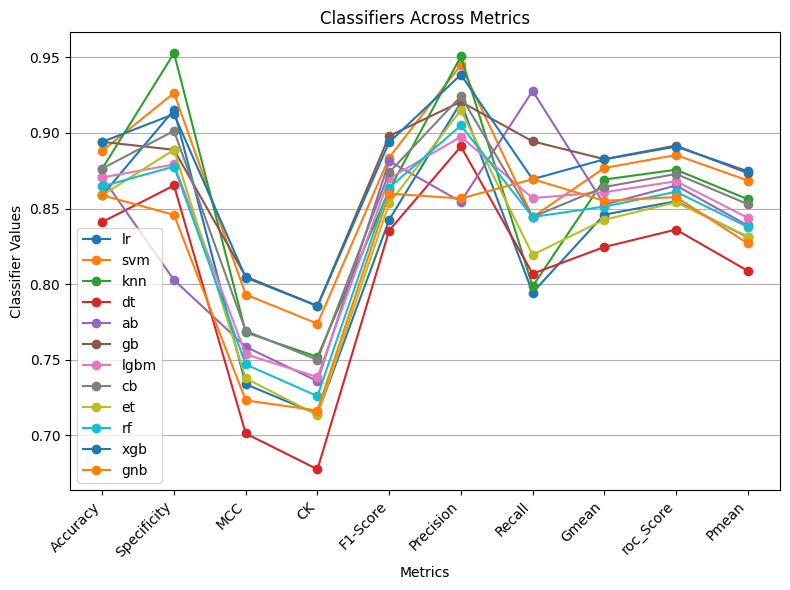

+++++++++++++++++++++++++++++++++++++++++++++End++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
weights =  [2.52380952 0.62352941]
FName  SMOTE Classifier  Accuracy  Specificity  MCC      CK       F1-Score  Precision  Recall   Gmean    roc_Score  Pmean  
KNNf  0        lr       0.782727  0.800000     0.519861 0.483204 0.844164  0.945437   0.775000 0.774402 0.787500   0.745811
KNNf  0       svm       0.784545  0.266667     0.195965 0.185351 0.868497  0.839073   0.906944 0.341160 0.586806   0.552779
KNNf  0       knn       0.839091  0.450000     0.418925 0.403173 0.902825  0.881540   0.929167 0.538484 0.689583   0.672532
KNNf  0        dt       0.717273  0.416667     0.185422 0.173876 0.814477  0.852850   0.788889 0.470287 0.602778   0.558057
KNNf  0        ab       0.829091  0.316667     0.293056 0.285363 0.899330  0.855177   0.951389 0.384464 0.634028   0.605396
KNNf  0        gb       0.745455  0.366667     0.228236 0.215536 0.834613  0.843644   0.833333 0.462380 0.600000

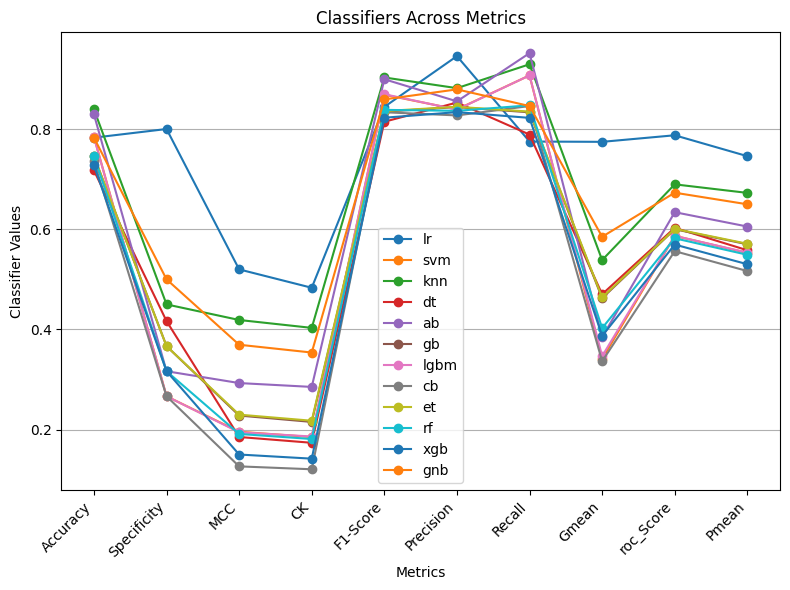

+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
weights =  [1. 1.]
FName  SMOTE Classifier  Accuracy  Specificity  MCC      CK       F1-Score  Precision  Recall   Gmean    roc_Score  Pmean  
KNNf  1        lr       0.852941  0.905556     0.720106 0.703902 0.836760  0.902937   0.797222 0.843919 0.851389   0.823859
KNNf  1       svm       0.858824  0.930556     0.735432 0.717266 0.843698  0.928492   0.787500 0.851614 0.859028   0.834712
KNNf  1       knn       0.717647  0.693056     0.440299 0.431226 0.721853  0.719553   0.738889 0.702714 0.715972   0.653467
KNNf  1        dt       0.829412  0.854167     0.670091 0.656369 0.828075  0.875310   0.800000 0.820882 0.827083   0.795710
KNNf  1        ab       0.876471  0.863889     0.768789 0.748972 0.881143  0.903574   0.881944 0.862568 0.872917   0.851141
KNNf  1        gb       0.847059  0.852778     0.710447 0.690687 0.848022  0.884263   0.834722 0.834025 0.843750   0.816195
KNNf  1

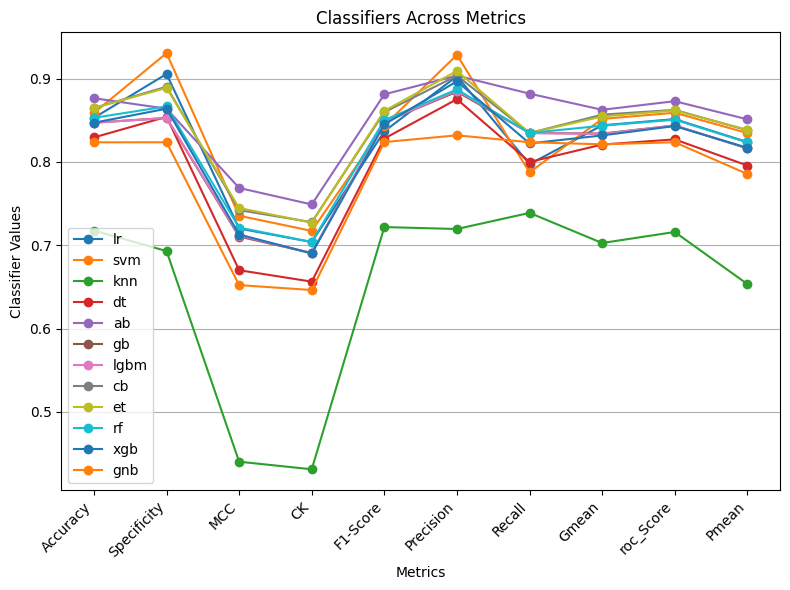

+++++++++++++++++++++++++++++++++++++++++++++End++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
weights =  [2.52380952 0.62352941]
FName  SMOTE Classifier  Accuracy  Specificity  MCC      CK       F1-Score  Precision  Recall   Gmean    roc_Score  Pmean  
SVRf  0        lr       0.811818  0.750000     0.512682 0.467165 0.869789  0.948485   0.820833 0.718685 0.785417   0.742764
SVRf  0       svm       0.801818  0.166667     0.127465 0.122779 0.883137  0.828543   0.951389 0.208088 0.559028   0.516546
SVRf  0       knn       0.761818  0.350000     0.170198 0.162730 0.851673  0.858120   0.855556 0.340569 0.602778   0.550382
SVRf  0        dt       0.811818  0.616667     0.430217 0.398143 0.877213  0.914199   0.858333 0.624343 0.737500   0.696493
SVRf  0        ab       0.838182  0.516667     0.452398 0.432503 0.899784  0.890588   0.915278 0.604235 0.715972   0.696178
SVRf  0        gb       0.839091  0.466667     0.430276 0.411720 0.900487  0.880310   0.927778 0.576078 0.697222

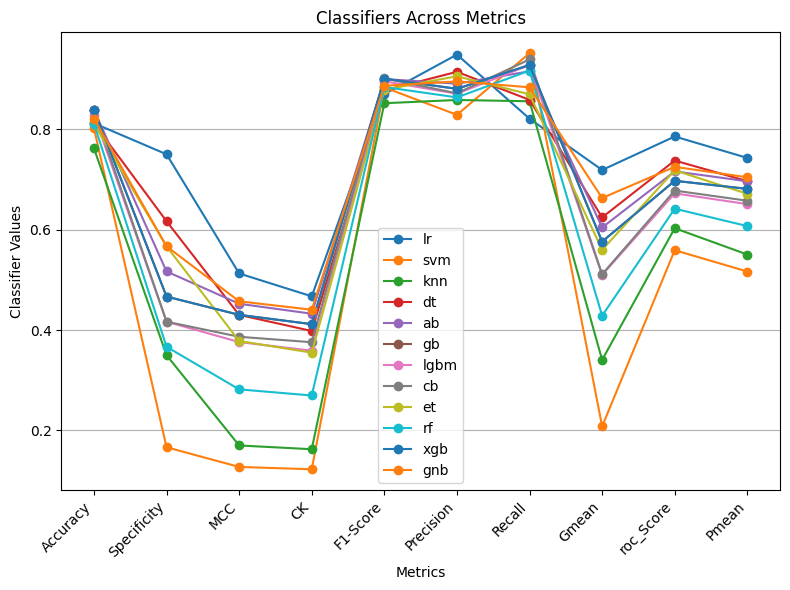

+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
weights =  [1. 1.]
FName  SMOTE Classifier  Accuracy  Specificity  MCC      CK       F1-Score  Precision  Recall   Gmean    roc_Score  Pmean  
SVRf  1        lr       0.888235  0.951389     0.787393 0.774427 0.874996  0.949722   0.820833 0.880438 0.886111   0.868172
SVRf  1       svm       0.900000  0.951389     0.808384 0.798877 0.892358  0.952103   0.845833 0.895098 0.898611   0.882517
SVRf  1       knn       0.841176  0.929167     0.702361 0.680103 0.819314  0.929881   0.748611 0.828569 0.838889   0.813119
SVRf  1        dt       0.882353  0.925000     0.776877 0.762037 0.878707  0.944167   0.833333 0.872067 0.879167   0.861523
SVRf  1        ab       0.852941  0.794444     0.730450 0.700546 0.862075  0.848803   0.902778 0.832519 0.848611   0.819241
SVRf  1        gb       0.905882  0.925000     0.826035 0.809581 0.905288  0.946731   0.881944 0.895967 0.903472   0.888878
SVRf  1

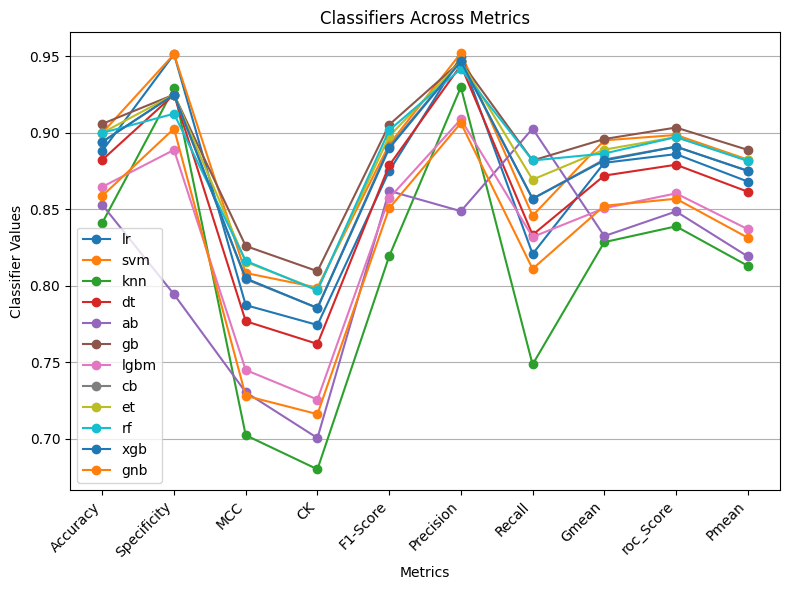

+++++++++++++++++++++++++++++++++++++++++++++End++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
weights =  [2.52380952 0.62352941]
FName  SMOTE Classifier  Accuracy  Specificity  MCC      CK       F1-Score  Precision  Recall   Gmean    roc_Score  Pmean  
RFf   0        lr       0.783636  0.666667     0.444844 0.413407 0.849692  0.914358   0.809722 0.675147 0.738194   0.699519
RFf   0       svm       0.811818  0.266667     0.221204 0.217190 0.888884  0.845303   0.941667 0.346564 0.604167   0.571496
RFf   0       knn       0.820909  0.366667     0.296111 0.287582 0.891013  0.863947   0.927778 0.434656 0.647222   0.615098
RFf   0        dt       0.753636  0.516667     0.298358 0.274163 0.835969  0.883128   0.808333 0.555081 0.662500   0.620871
RFf   0        ab       0.870000  0.616667     0.564582 0.551040 0.918250  0.911699   0.929167 0.705890 0.772917   0.760023
RFf   0        gb       0.811818  0.416667     0.349917 0.338175 0.883838  0.867096   0.906944 0.541474 0.661806

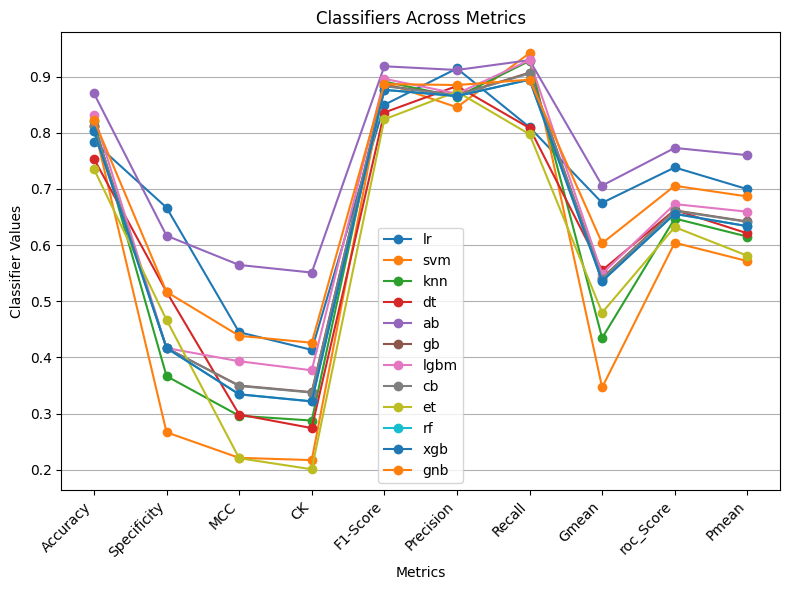

+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
weights =  [1. 1.]
FName  SMOTE Classifier  Accuracy  Specificity  MCC      CK       F1-Score  Precision  Recall   Gmean    roc_Score  Pmean  
RFf   1        lr       0.870588  0.877778     0.750179 0.738931 0.867529  0.890000   0.858333 0.862927 0.868056   0.842702
RFf   1       svm       0.888235  0.926389     0.789211 0.775081 0.882698  0.937103   0.845833 0.880296 0.886111   0.867884
RFf   1       knn       0.882353  0.938889     0.780916 0.764172 0.873373  0.947096   0.823611 0.874765 0.881250   0.862936
RFf   1        dt       0.835294  0.840278     0.688777 0.665063 0.836072  0.881811   0.819444 0.815703 0.829861   0.801367
RFf   1        ab       0.917647  0.887500     0.851265 0.831689 0.925656  0.928462   0.940278 0.903669 0.913889   0.900006
RFf   1        gb       0.858824  0.852778     0.730351 0.714630 0.863777  0.886756   0.858333 0.846996 0.855556   0.829778
RFf   1

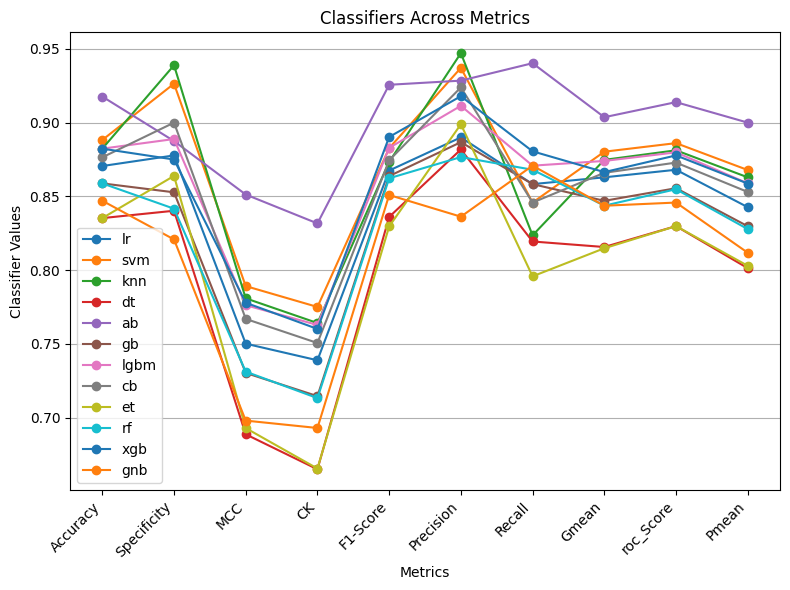

+++++++++++++++++++++++++++++++++++++++++++++End++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
weights =  [2.52380952 0.62352941]
FName  SMOTE Classifier  Accuracy  Specificity  MCC      CK       F1-Score  Precision  Recall   Gmean    roc_Score  Pmean  
XGBf  0        lr       0.792727  0.800000     0.530918 0.483341 0.852121  0.952381   0.787500 0.773945 0.793750   0.751854
XGBf  0       svm       0.839091  0.366667     0.308321 0.305629 0.905278  0.868914   0.952778 0.403251 0.659722   0.623294
XGBf  0       knn       0.850000  0.516667     0.485125 0.467163 0.907972  0.891263   0.929167 0.648194 0.722917   0.713163
XGBf  0        dt       0.800000  0.616667     0.413127 0.399205 0.870229  0.904239   0.844444 0.669435 0.730556   0.694211
XGBf  0        ab       0.810909  0.316667     0.262558 0.255139 0.886041  0.851573   0.927778 0.378799 0.622222   0.590187
XGBf  0        gb       0.829091  0.566667     0.434103 0.421672 0.893317  0.899477   0.893056 0.623761 0.729861

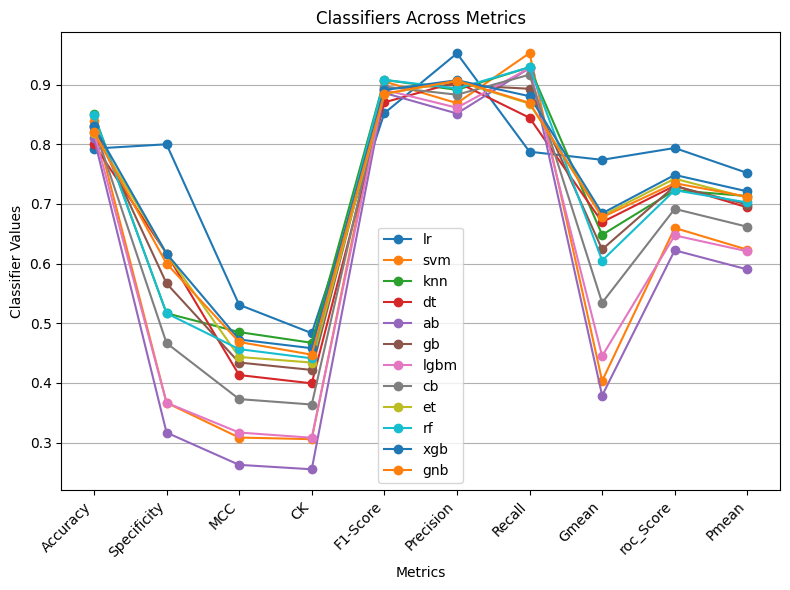

+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
weights =  [1. 1.]
FName  SMOTE Classifier  Accuracy  Specificity  MCC      CK       F1-Score  Precision  Recall   Gmean    roc_Score  Pmean  
XGBf  1        lr       0.847059  0.891667     0.701109 0.692033 0.835193  0.887540   0.798611 0.840339 0.845139   0.815410
XGBf  1       svm       0.835294  0.876389     0.678898 0.667771 0.831219  0.890942   0.787500 0.826743 0.831944   0.802967
XGBf  1       knn       0.835294  0.913889     0.684033 0.667912 0.819190  0.916270   0.751389 0.825043 0.832639   0.805073
XGBf  1        dt       0.864706  0.862500     0.742128 0.725558 0.866190  0.896212   0.855556 0.851654 0.859028   0.835948
XGBf  1        ab       0.882353  0.900000     0.775317 0.761882 0.882225  0.924545   0.858333 0.873014 0.879167   0.859648
XGBf  1        gb       0.882353  0.875000     0.777052 0.761059 0.885471  0.909545   0.879167 0.869955 0.877083   0.857409
XGBf  1

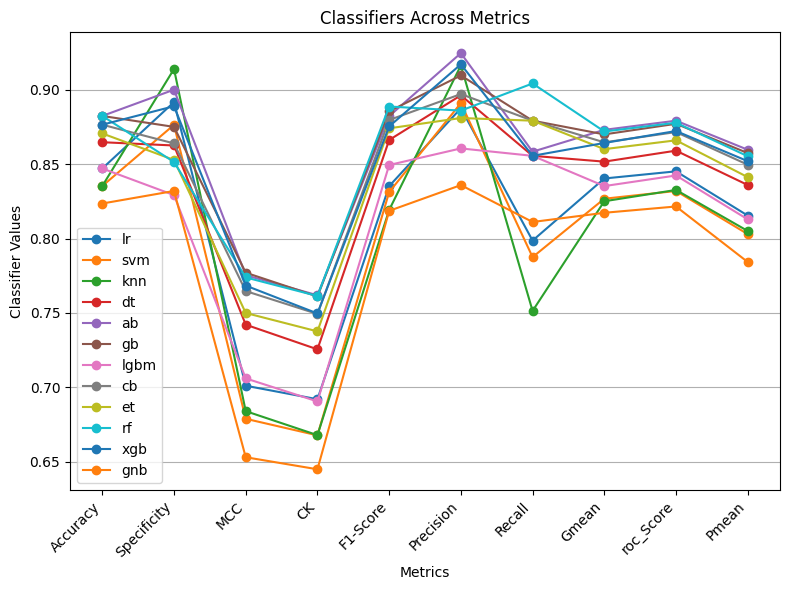

+++++++++++++++++++++++++++++++++++++++++++++End++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
weights =  [2.52380952 0.62352941]
FName  SMOTE Classifier  Accuracy  Specificity  MCC      CK       F1-Score  Precision  Recall   Gmean    roc_Score  Pmean  
LGBMf 0        lr       0.819091  0.800000     0.560184 0.521678 0.876901  0.950714   0.822222 0.795844 0.811111   0.773083
LGBMf 0       svm       0.820909  0.266667     0.249397 0.240370 0.894732  0.846414   0.952778 0.350608 0.609722   0.581289
LGBMf 0       knn       0.760909  0.266667     0.139848 0.138220 0.853648  0.833802   0.879167 0.307512 0.572917   0.528077
LGBMf 0        dt       0.811818  0.516667     0.382794 0.366772 0.880469  0.889199   0.881944 0.584143 0.699306   0.668124
LGBMf 0        ab       0.857273  0.516667     0.492417 0.465448 0.912819  0.895985   0.940278 0.607476 0.728472   0.712981
LGBMf 0        gb       0.810909  0.416667     0.307223 0.303821 0.883562  0.869199   0.905556 0.497279 0.661111

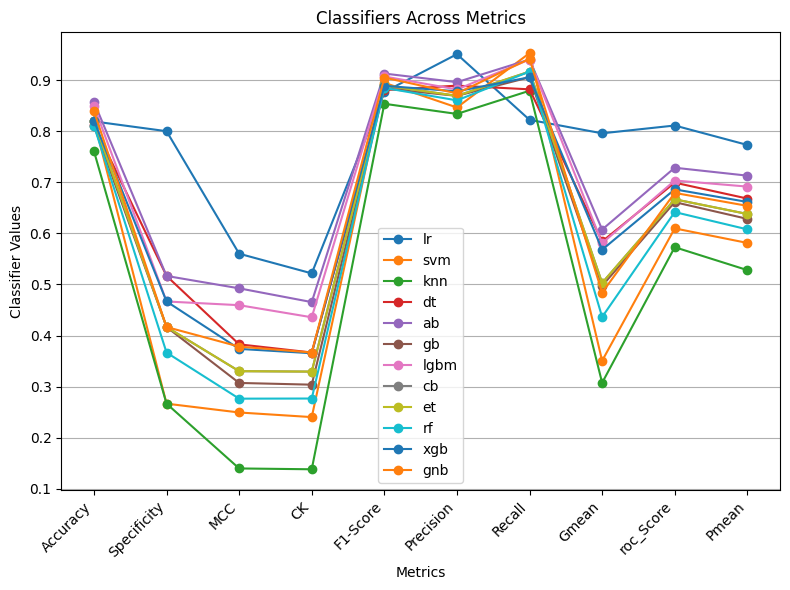

+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
weights =  [1. 1.]
FName  SMOTE Classifier  Accuracy  Specificity  MCC      CK       F1-Score  Precision  Recall   Gmean    roc_Score  Pmean  
LGBMf 1        lr       0.870588  0.904167     0.749652 0.739764 0.864827  0.909199   0.833333 0.864959 0.868750   0.845027
LGBMf 1       svm       0.888235  0.927778     0.784921 0.776081 0.882211  0.929881   0.847222 0.884128 0.887500   0.867551
LGBMf 1       knn       0.864706  0.904167     0.741661 0.727023 0.860140  0.919048   0.822222 0.855808 0.863194   0.839774
LGBMf 1        dt       0.864706  0.902778     0.741319 0.728193 0.860750  0.915310   0.823611 0.857957 0.863194   0.839758
LGBMf 1        ab       0.870588  0.805556     0.758343 0.736553 0.883037  0.855612   0.927778 0.853413 0.866667   0.839727
LGBMf 1        gb       0.870588  0.890278     0.755533 0.739407 0.869447  0.911219   0.847222 0.861684 0.868750   0.846014
LGBMf 1

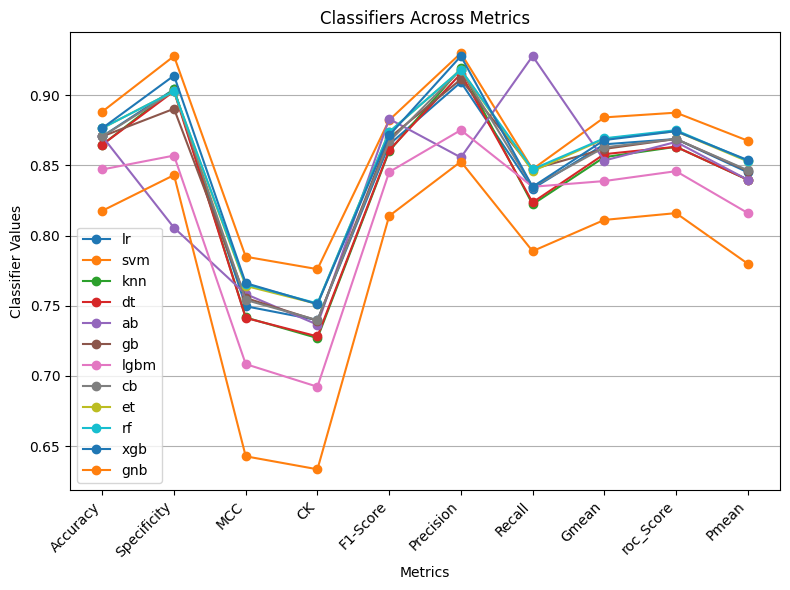

+++++++++++++++++++++++++++++++++++++++++++++End++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
weights =  [2.52380952 0.62352941]
FName  SMOTE Classifier  Accuracy  Specificity  MCC      CK       F1-Score  Precision  Recall   Gmean    roc_Score  Pmean  
BORf  0        lr       0.800909  0.850000     0.547858 0.511057 0.859605  0.958333   0.786111 0.808100 0.818056   0.771114
BORf  0       svm       0.812727  0.366667     0.332805 0.316735 0.885881  0.858763   0.919444 0.483680 0.643056   0.624417
BORf  0       knn       0.830000  0.516667     0.440468 0.426881 0.894020  0.886977   0.905556 0.606126 0.711111   0.690867
BORf  0        dt       0.803636  0.366667     0.317214 0.300304 0.878381  0.856977   0.906944 0.478014 0.636806   0.616105
BORf  0        ab       0.849091  0.366667     0.398053 0.377770 0.910487  0.865303   0.963889 0.492029 0.665278   0.654285
BORf  0        gb       0.812727  0.366667     0.332805 0.316735 0.885881  0.858763   0.919444 0.483680 0.643056

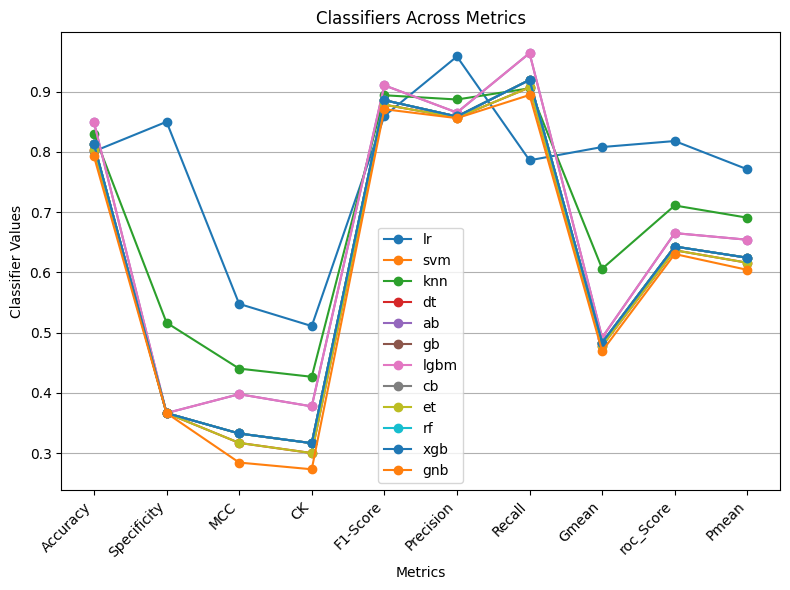

+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
weights =  [1. 1.]
FName  SMOTE Classifier  Accuracy  Specificity  MCC      CK       F1-Score  Precision  Recall   Gmean    roc_Score  Pmean  
BORf  1        lr       0.841176  0.894444     0.690815 0.681140 0.831118  0.890317   0.786111 0.836225 0.840278   0.810181
BORf  1       svm       0.847059  0.883333     0.702556 0.693520 0.840093  0.882540   0.811111 0.843547 0.847222   0.816776
BORf  1       knn       0.729412  0.636111     0.468619 0.457470 0.759384  0.736032   0.825000 0.670851 0.730556   0.668159
BORf  1        dt       0.864706  0.904167     0.738933 0.727535 0.856021  0.906825   0.822222 0.857996 0.863194   0.837955
BORf  1        ab       0.864706  0.925000     0.748900 0.726518 0.852726  0.941667   0.797222 0.851355 0.861111   0.841023
BORf  1        gb       0.876471  0.926389     0.767264 0.750972 0.867230  0.937778   0.822222 0.867470 0.874306   0.854456
BORf  1

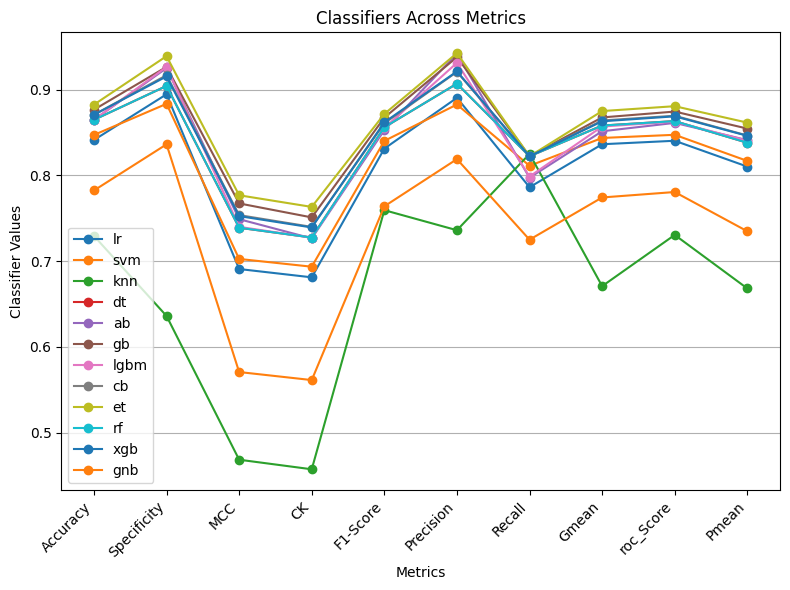

+++++++++++++++++++++++++++++++++++++++++++++End++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
weights =  [2.52380952 0.62352941]
FName  SMOTE Classifier  Accuracy  Specificity  MCC      CK       F1-Score  Precision  Recall   Gmean    roc_Score  Pmean  
RFEf  0        lr       0.668182  0.800000     0.356654 0.286993 0.738376  0.946825   0.630556 0.649459 0.715278   0.643591
RFEf  0       svm       0.858182  0.416667     0.430971 0.415701 0.915750  0.875303   0.963889 0.521319 0.690278   0.676451
RFEf  0       knn       0.840000  0.416667     0.402892 0.385673 0.899678  0.871136   0.938889 0.509492 0.677778   0.660245
RFEf  0        dt       0.858182  0.416667     0.430971 0.415701 0.915750  0.875303   0.963889 0.521319 0.690278   0.676451
RFEf  0        ab       0.858182  0.416667     0.430971 0.415701 0.915750  0.875303   0.963889 0.521319 0.690278   0.676451
RFEf  0        gb       0.858182  0.416667     0.430971 0.415701 0.915750  0.875303   0.963889 0.521319 0.690278

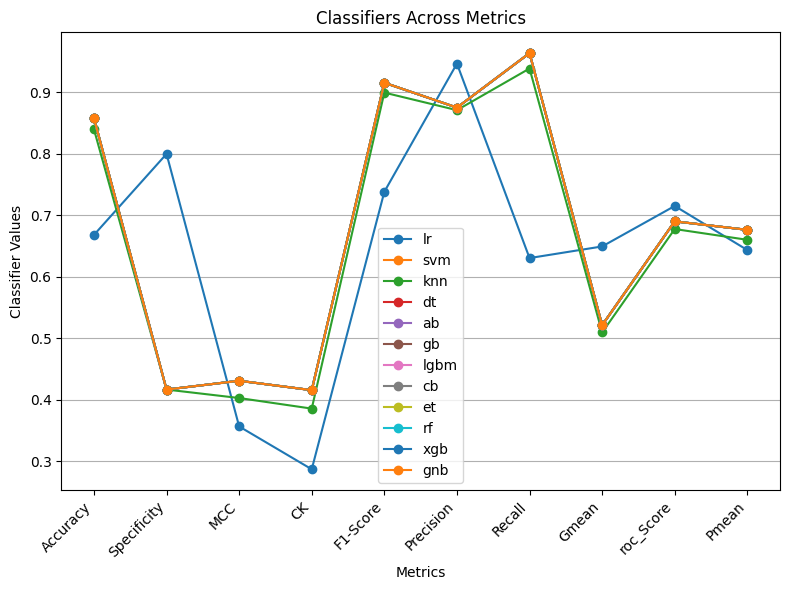

+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
weights =  [1. 1.]
FName  SMOTE Classifier  Accuracy  Specificity  MCC      CK       F1-Score  Precision  Recall   Gmean    roc_Score  Pmean  
RFEf  1        lr       0.823529  0.929167     0.663320 0.645090 0.797001  0.911548   0.715278 0.812361 0.822222   0.791057
RFEf  1       svm       0.823529  0.929167     0.664572 0.645086 0.796781  0.913929   0.715278 0.811929 0.822222   0.791388
RFEf  1       knn       0.741176  0.606944     0.509312 0.477658 0.770675  0.704312   0.866667 0.711450 0.736806   0.680555
RFEf  1        dt       0.829412  0.940278     0.678111 0.656807 0.802495  0.928214   0.715278 0.816882 0.827778   0.799473
RFEf  1        ab       0.805882  0.833333     0.627925 0.608435 0.796082  0.849351   0.772222 0.791749 0.802778   0.765306
RFEf  1        gb       0.835294  0.951389     0.691651 0.668528 0.808209  0.942500   0.715278 0.821835 0.833333   0.807558
RFEf  1

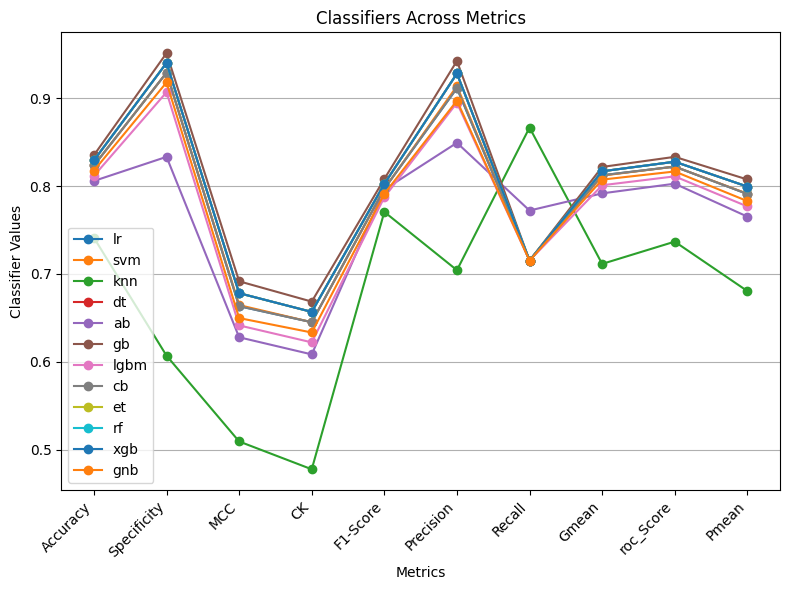

+++++++++++++++++++++++++++++++++++++++++++++End++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
weights =  [2.52380952 0.62352941]
FName  SMOTE Classifier  Accuracy  Specificity  MCC      CK       F1-Score  Precision  Recall   Gmean    roc_Score  Pmean  
FORWf 0        lr       0.810000  0.750000     0.511058 0.476775 0.871296  0.940992   0.822222 0.730544 0.786111   0.744333
FORWf 0       svm       0.800909  0.166667     0.128564 0.125947 0.884356  0.827803   0.952778 0.213754 0.559722   0.517833
FORWf 0       knn       0.828182  0.316667     0.323041 0.307837 0.899058  0.853056   0.952778 0.426592 0.634722   0.615770
FORWf 0        dt       0.736364  0.350000     0.157494 0.155051 0.834064  0.843088   0.834722 0.409678 0.592361   0.545869
FORWf 0        ab       0.840000  0.516667     0.454430 0.431390 0.901436  0.892652   0.918056 0.603575 0.717361   0.697285
FORWf 0        gb       0.792727  0.416667     0.284848 0.278157 0.871548  0.868763   0.881944 0.495266 0.649306

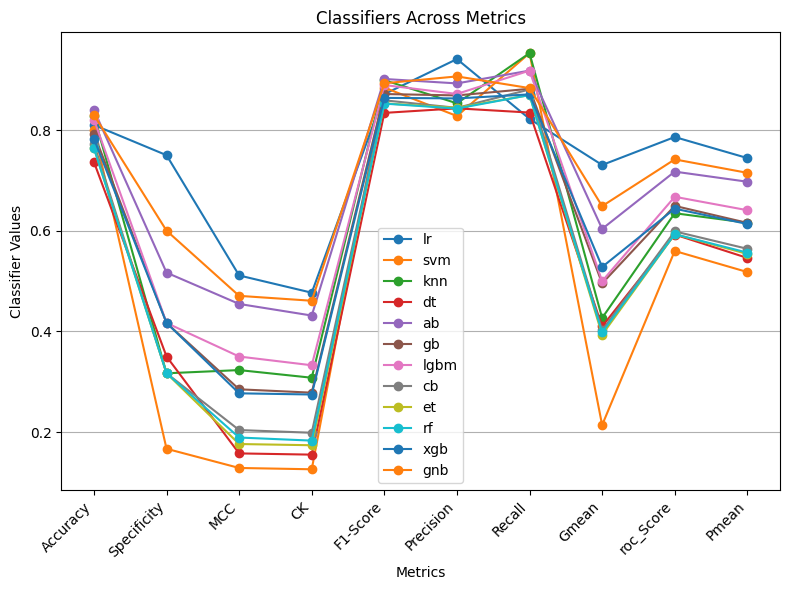

+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
weights =  [1. 1.]
FName  SMOTE Classifier  Accuracy  Specificity  MCC      CK       F1-Score  Precision  Recall   Gmean    roc_Score  Pmean  
FORWf 1        lr       0.888235  0.937500     0.784625 0.775265 0.882616  0.943889   0.834722 0.882573 0.886111   0.868393
FORWf 1       svm       0.900000  0.975000     0.812822 0.799193 0.889282  0.975714   0.822222 0.893562 0.898611   0.885156
FORWf 1       knn       0.847059  0.987500     0.727355 0.690922 0.808373  0.988889   0.701389 0.825495 0.844444   0.824603
FORWf 1        dt       0.852941  0.862500     0.722375 0.700070 0.855554  0.910023   0.831944 0.832822 0.847222   0.823939
FORWf 1        ab       0.876471  0.837500     0.773269 0.747430 0.891221  0.900183   0.905556 0.855253 0.871528   0.850934
FORWf 1        gb       0.870588  0.850000     0.754048 0.735577 0.880963  0.903205   0.880556 0.852308 0.865278   0.843614
FORWf 1

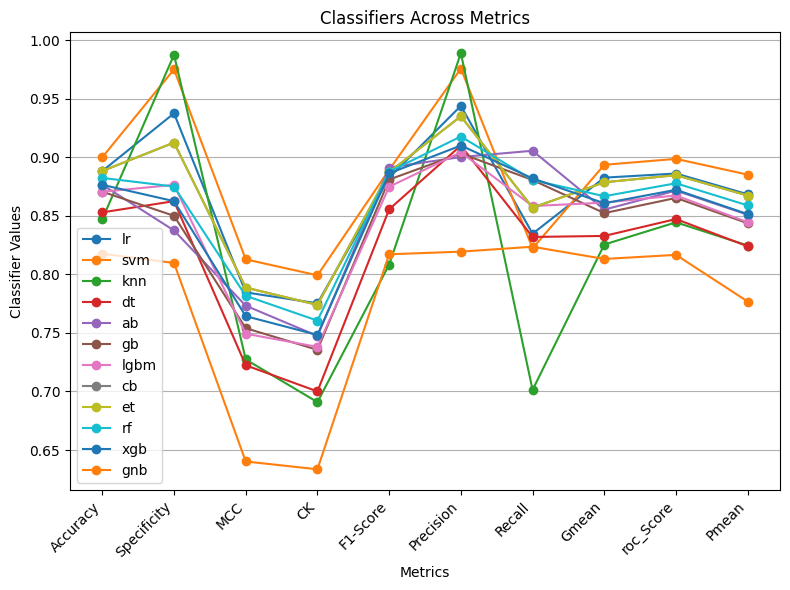

+++++++++++++++++++++++++++++++++++++++++++++End++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
weights =  [2.52380952 0.62352941]
FName   SMOTE Classifier  Accuracy  Specificity  MCC      CK       F1-Score  Precision  Recall   Gmean    roc_Score  Pmean  
BACKWf 0        lr       0.716364  0.700000     0.367416 0.316377 0.795307  0.923214   0.715278 0.651463 0.707639   0.654784
BACKWf 0       svm       0.857273  0.316667     0.382393 0.359664 0.917724  0.858914   0.987500 0.430636 0.652083   0.640317
BACKWf 0       knn       0.839091  0.316667     0.360171 0.337442 0.905501  0.854874   0.965278 0.430636 0.640972   0.627848
BACKWf 0        dt       0.857273  0.316667     0.382393 0.359664 0.917724  0.858914   0.987500 0.430636 0.652083   0.640317
BACKWf 0        ab       0.857273  0.316667     0.382393 0.359664 0.917724  0.858914   0.987500 0.430636 0.652083   0.640317
BACKWf 0        gb       0.857273  0.316667     0.382393 0.359664 0.917724  0.858914   0.987500 0.430636 0

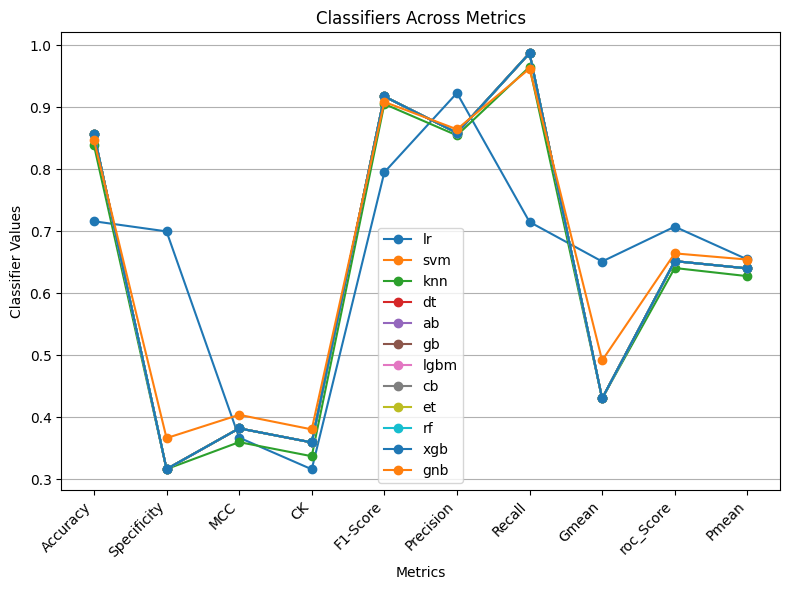

+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
weights =  [1. 1.]
FName   SMOTE Classifier  Accuracy  Specificity  MCC      CK       F1-Score  Precision  Recall   Gmean    roc_Score  Pmean  
BACKWf 1        lr       0.800000  0.847222     0.609137 0.596570 0.786363  0.842500   0.750000 0.790188 0.798611   0.757844
BACKWf 1       svm       0.811765  0.845833     0.630849 0.620860 0.804596  0.847817   0.775000 0.804355 0.810417   0.772388
BACKWf 1       knn       0.782353  0.638889     0.616578 0.565668 0.815720  0.747912   0.930556 0.749215 0.784722   0.736846
BACKWf 1        dt       0.817647  0.820833     0.641424 0.632427 0.819788  0.841825   0.809722 0.809844 0.815278   0.778754
BACKWf 1        ab       0.817647  0.820833     0.647937 0.632239 0.816756  0.843001   0.809722 0.807105 0.815278   0.778946
BACKWf 1        gb       0.817647  0.820833     0.641424 0.632427 0.819788  0.841825   0.809722 0.809844 0.815278   0.778754


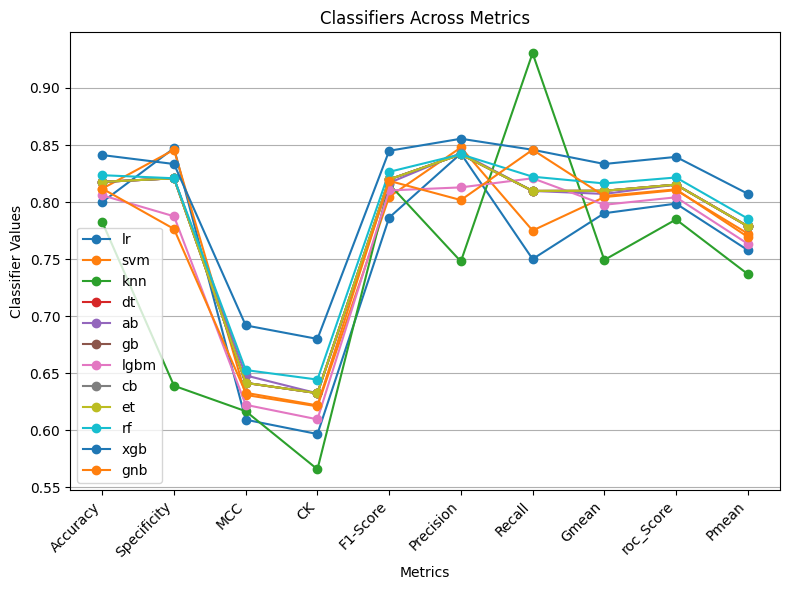

+++++++++++++++++++++++++++++++++++++++++++++End++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
weights =  [2.52380952 0.62352941]
FName  SMOTE Classifier  Accuracy  Specificity  MCC      CK       F1-Score  Precision  Recall   Gmean    roc_Score  Pmean  
ANOf  0        lr       0.800909  0.850000     0.547858 0.511057 0.859605  0.958333   0.786111 0.808100 0.818056   0.771114
ANOf  0       svm       0.792727  0.366667     0.307805 0.291735 0.871992  0.853763   0.894444 0.483680 0.630556   0.610374
ANOf  0       knn       0.838182  0.450000     0.409794 0.390199 0.901812  0.882803   0.927778 0.532765 0.688889   0.669136
ANOf  0        dt       0.774545  0.366667     0.264021 0.252124 0.858644  0.850866   0.870833 0.473970 0.618750   0.592269
ANOf  0        ab       0.849091  0.366667     0.398053 0.377770 0.910487  0.865303   0.963889 0.492029 0.665278   0.654285
ANOf  0        gb       0.792727  0.366667     0.307805 0.291735 0.871992  0.853763   0.894444 0.483680 0.630556

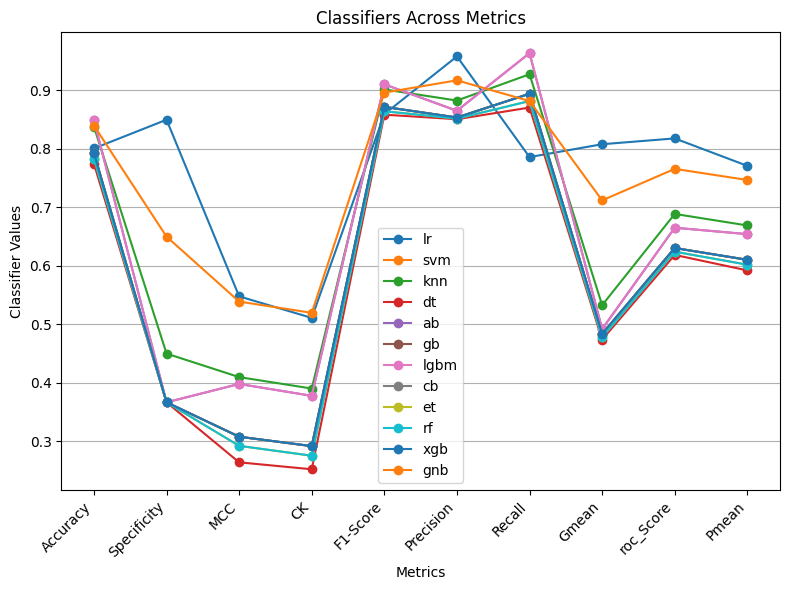

+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
weights =  [1. 1.]
FName  SMOTE Classifier  Accuracy  Specificity  MCC      CK       F1-Score  Precision  Recall   Gmean    roc_Score  Pmean  
ANOf  1        lr       0.829412  0.872222     0.667352 0.657844 0.818041  0.866270   0.786111 0.824527 0.829167   0.794550
ANOf  1       svm       0.817647  0.845833     0.645839 0.633241 0.808959  0.850040   0.787500 0.810454 0.816667   0.779576
ANOf  1       knn       0.770588  0.691667     0.556622 0.537554 0.786460  0.750152   0.843056 0.753141 0.767361   0.717400
ANOf  1        dt       0.876471  0.926389     0.767264 0.750972 0.867230  0.937778   0.822222 0.867470 0.874306   0.854456
ANOf  1        ab       0.864706  0.912500     0.751622 0.725840 0.854678  0.937009   0.808333 0.848358 0.860417   0.840385
ANOf  1        gb       0.882353  0.937500     0.778376 0.762697 0.873113  0.948889   0.822222 0.873189 0.879861   0.862022
ANOf  1

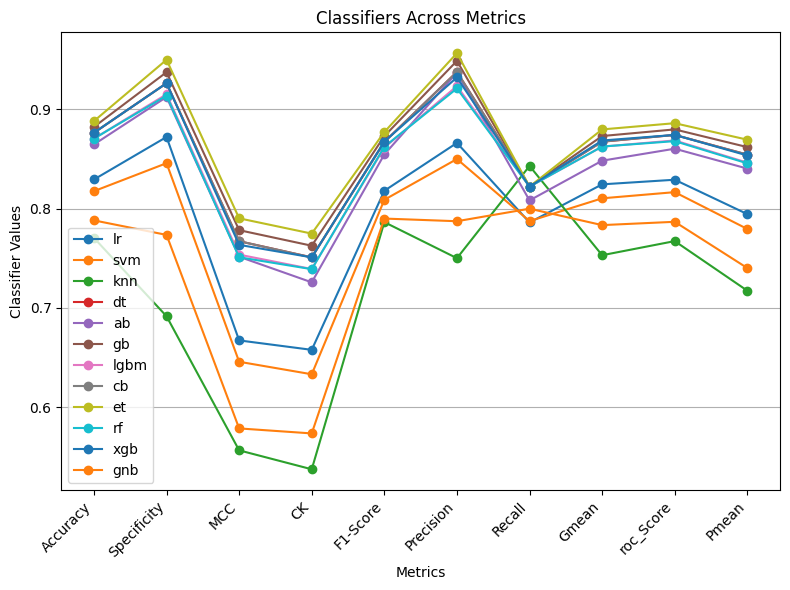

+++++++++++++++++++++++++++++++++++++++++++++End++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
weights =  [2.52380952 0.62352941]
FName  SMOTE Classifier  Accuracy  Specificity  MCC      CK       F1-Score  Precision  Recall   Gmean    roc_Score  Pmean  
PEARf 0        lr       0.761818  0.700000     0.416448 0.392558 0.836578  0.916270   0.775000 0.693472 0.737500   0.692183
PEARf 0       svm       0.801818  0.200000     0.162995 0.161557 0.884459  0.828914   0.952778 0.270188 0.576389   0.537678
PEARf 0       knn       0.790909  0.250000     0.201201 0.194853 0.876767  0.833561   0.929167 0.307565 0.589583   0.552623
PEARf 0        dt       0.696364  0.366667     0.119692 0.117632 0.799294  0.836587   0.773611 0.435125 0.570139   0.523901
PEARf 0        ab       0.838182  0.500000     0.448682 0.429088 0.900701  0.889874   0.916667 0.599431 0.708333   0.692329
PEARf 0        gb       0.782727  0.416667     0.276121 0.273711 0.862908  0.862413   0.869444 0.526596 0.643056

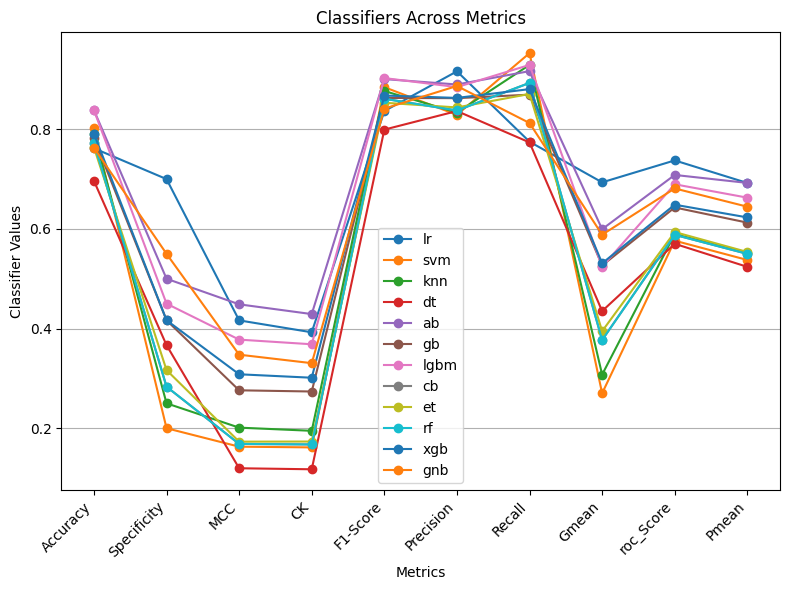

+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
weights =  [1. 1.]
FName  SMOTE Classifier  Accuracy  Specificity  MCC      CK       F1-Score  Precision  Recall   Gmean    roc_Score  Pmean  
PEARf 1        lr       0.805882  0.841667     0.618047 0.608825 0.797198  0.846667   0.763889 0.798049 0.802778   0.764778
PEARf 1       svm       0.876471  0.937500     0.767660 0.750938 0.858327  0.940000   0.809722 0.864689 0.873611   0.853213
PEARf 1       knn       0.852941  0.950000     0.726597 0.705024 0.832786  0.950992   0.752778 0.841590 0.851389   0.829344
PEARf 1        dt       0.817647  0.850000     0.653746 0.627560 0.808882  0.894266   0.772222 0.793194 0.811111   0.780959
PEARf 1        ab       0.882353  0.850000     0.773581 0.760524 0.894912  0.896766   0.906944 0.868729 0.878472   0.856920
PEARf 1        gb       0.841176  0.837500     0.696425 0.675973 0.846466  0.889064   0.831944 0.820970 0.834722   0.808249
PEARf 1

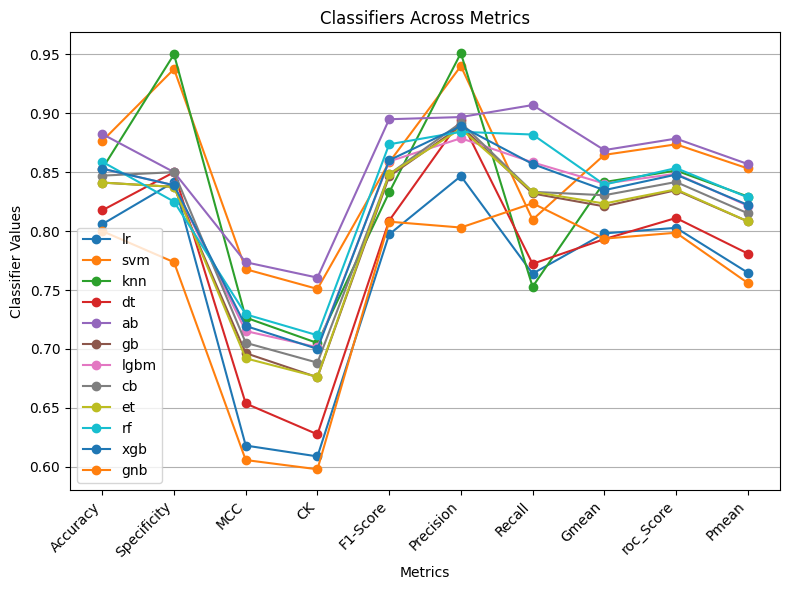

+++++++++++++++++++++++++++++++++++++++++++++End++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
weights =  [2.52380952 0.62352941]
FName   SMOTE Classifier  Accuracy  Specificity  MCC      CK       F1-Score  Precision  Recall   Gmean    roc_Score  Pmean  
LASSOf 0        lr       0.810000  0.750000     0.511058 0.476775 0.871296  0.940992   0.822222 0.730544 0.786111   0.744333
LASSOf 0       svm       0.801818  0.166667     0.128148 0.125416 0.884848  0.828510   0.952778 0.213754 0.559722   0.517962
LASSOf 0       knn       0.838182  0.416667     0.371816 0.356371 0.904272  0.875556   0.941667 0.477560 0.679167   0.651251
LASSOf 0        dt       0.734545  0.466667     0.248250 0.229414 0.822902  0.867056   0.797222 0.525090 0.631944   0.591454
LASSOf 0        ab       0.849091  0.516667     0.484151 0.450816 0.906201  0.895985   0.929167 0.600680 0.722917   0.706186
LASSOf 0        gb       0.745455  0.316667     0.142632 0.141255 0.839194  0.840628   0.847222 0.384854 0

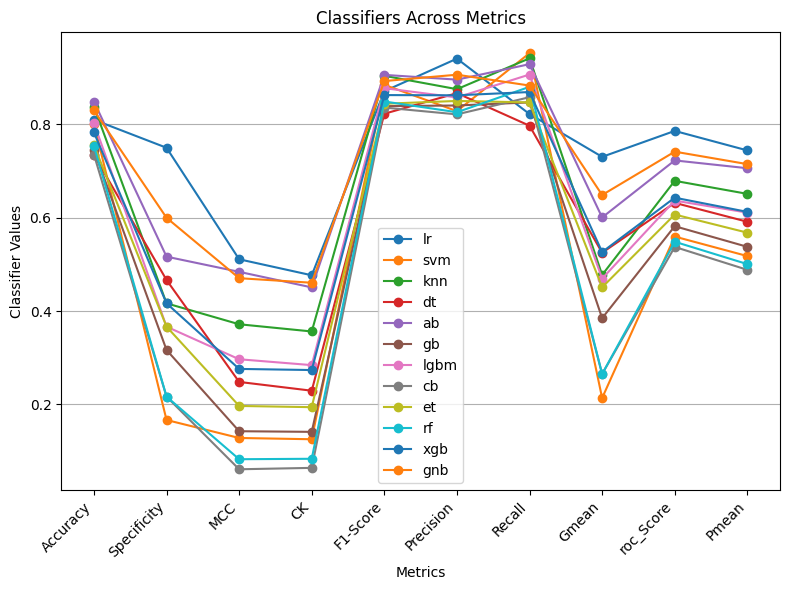

+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
weights =  [1. 1.]
FName   SMOTE Classifier  Accuracy  Specificity  MCC      CK       F1-Score  Precision  Recall   Gmean    roc_Score  Pmean  
LASSOf 1        lr       0.888235  0.951389     0.784438 0.775589 0.878455  0.947817   0.822222 0.883282 0.886806   0.868693
LASSOf 1       svm       0.882353  0.952778     0.774578 0.764027 0.871886  0.947817   0.811111 0.877909 0.881944   0.862712
LASSOf 1       knn       0.823529  1.000000     0.691467 0.642810 0.770180  1.000000   0.641667 0.794715 0.820833   0.798356
LASSOf 1        dt       0.829412  0.838889     0.671062 0.653035 0.833303  0.882684   0.809722 0.812289 0.824306   0.794967
LASSOf 1        ab       0.894118  0.863889     0.801077 0.784637 0.902960  0.903430   0.918056 0.881644 0.890972   0.871198
LASSOf 1        gb       0.858824  0.838889     0.732280 0.713144 0.866265  0.882867   0.869444 0.843843 0.854167   0.828858


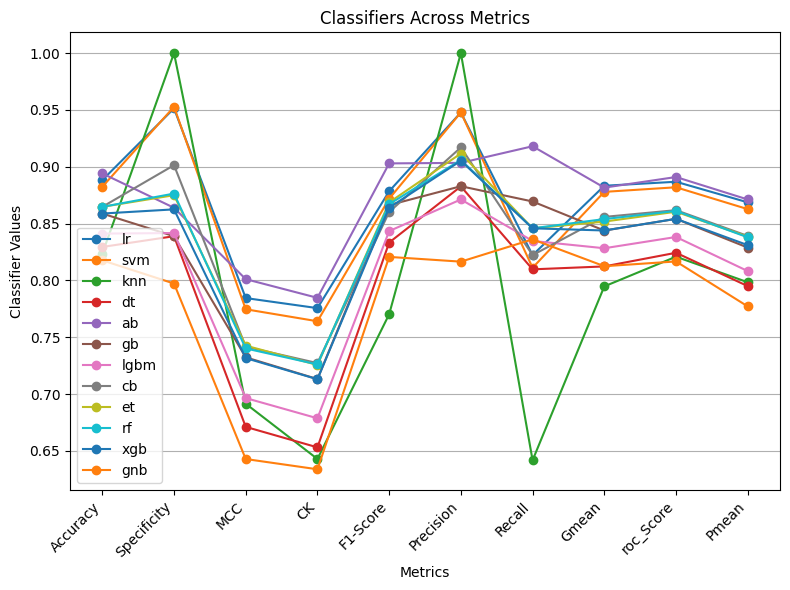

+++++++++++++++++++++++++++++++++++++++++++++End++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
weights =  [2.52380952 0.62352941]
FName  SMOTE Classifier  Accuracy  Specificity  MCC      CK       F1-Score  Precision  Recall   Gmean    roc_Score  Pmean  
Uf    0        lr       0.810000  0.750000     0.511058 0.476775 0.871296  0.940992   0.822222 0.730544 0.786111   0.744333
Uf    0       svm       0.801818  0.166667     0.128148 0.125416 0.884848  0.828510   0.952778 0.213754 0.559722   0.517962
Uf    0       knn       0.838182  0.416667     0.371816 0.356371 0.904272  0.875556   0.941667 0.477560 0.679167   0.651251
Uf    0        dt       0.724545  0.516667     0.246718 0.224378 0.813482  0.877850   0.773611 0.539625 0.645139   0.595779
Uf    0        ab       0.849091  0.516667     0.484151 0.450816 0.906201  0.895985   0.929167 0.600680 0.722917   0.706186
Uf    0        gb       0.745455  0.316667     0.142632 0.141255 0.839194  0.840628   0.847222 0.384854 0.581944

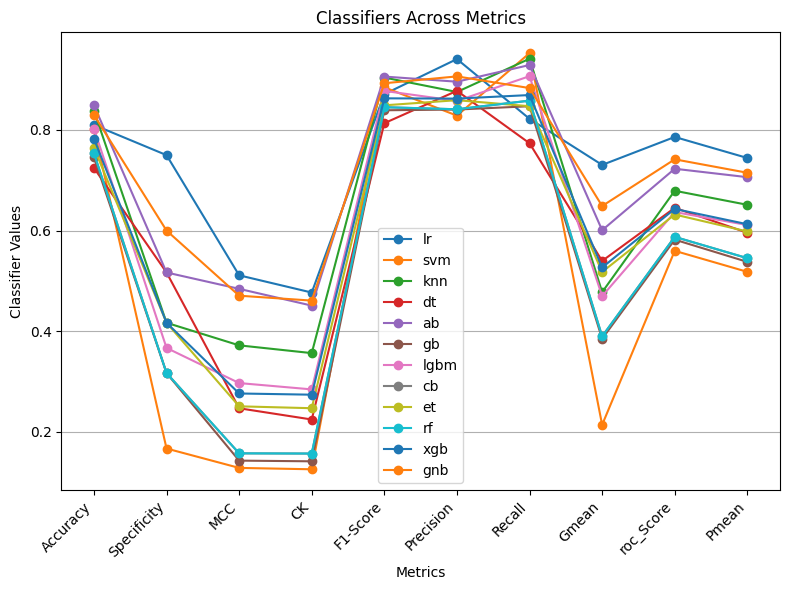

+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
weights =  [1. 1.]
FName  SMOTE Classifier  Accuracy  Specificity  MCC      CK       F1-Score  Precision  Recall   Gmean    roc_Score  Pmean  
Uf    1        lr       0.858824  0.894444     0.733035 0.716782 0.850103  0.902532   0.820833 0.850946 0.857639   0.831682
Uf    1       svm       0.905882  0.987500     0.825572 0.811407 0.896053  0.988889   0.823611 0.900424 0.905556   0.893877
Uf    1       knn       0.858824  0.987500     0.745636 0.715402 0.829077  0.987500   0.726389 0.842753 0.856944   0.838892
Uf    1        dt       0.829412  0.863889     0.670923 0.654186 0.828858  0.898359   0.787500 0.814485 0.825694   0.797034
Uf    1        ab       0.882353  0.827778     0.783195 0.760159 0.896685  0.883730   0.930556 0.865078 0.879167   0.856522
Uf    1        gb       0.870588  0.850000     0.760274 0.735726 0.879973  0.905769   0.880556 0.850263 0.865278   0.844270
Uf    1

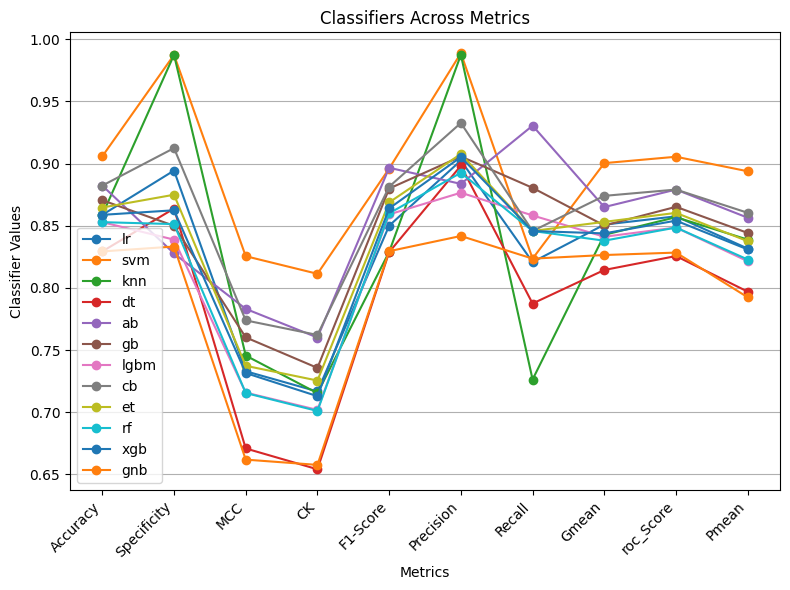

+++++++++++++++++++++++++++++++++++++++++++++End++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
weights =  [2.52380952 0.62352941]
FName              SMOTE Classifier  Accuracy  Specificity  MCC      CK       F1-Score  Precision  Recall   Gmean    roc_Score  Pmean  
majority_features 0        lr       0.811818  0.750000     0.512682 0.467165 0.869789  0.948485   0.820833 0.718685 0.785417   0.742764
majority_features 0       svm       0.801818  0.166667     0.127465 0.122779 0.883137  0.828543   0.951389 0.208088 0.559028   0.516546
majority_features 0       knn       0.761818  0.350000     0.170198 0.162730 0.851673  0.858120   0.855556 0.340569 0.602778   0.550382
majority_features 0        dt       0.811818  0.616667     0.430217 0.398143 0.877213  0.914199   0.858333 0.624343 0.737500   0.696493
majority_features 0        ab       0.838182  0.516667     0.452398 0.432503 0.899784  0.890588   0.915278 0.604235 0.715972   0.696178
majority_features 0        gb       0.83

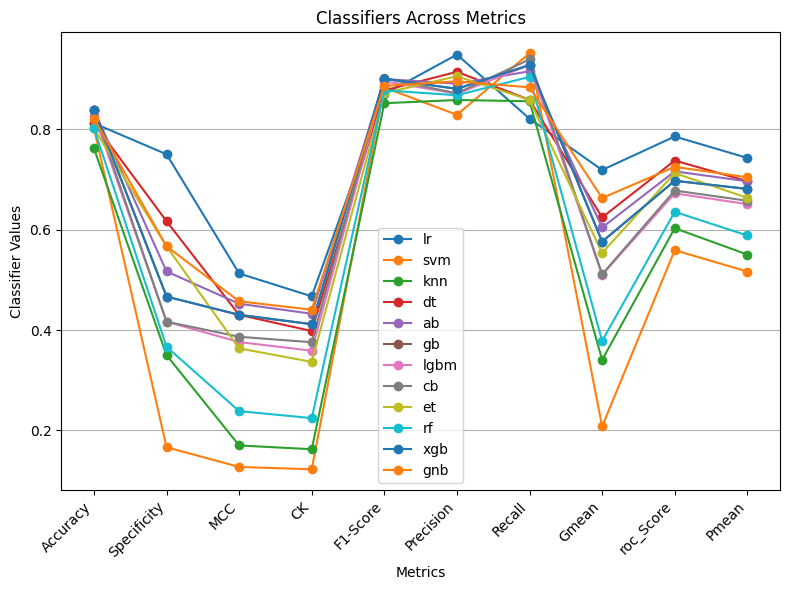

+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
weights =  [1. 1.]
FName              SMOTE Classifier  Accuracy  Specificity  MCC      CK       F1-Score  Precision  Recall   Gmean    roc_Score  Pmean  
majority_features 1        lr       0.864706  0.879167     0.744849 0.726029 0.860854  0.901731   0.843056 0.852125 0.861111   0.837070
majority_features 1       svm       0.876471  0.913889     0.760344 0.751649 0.869951  0.917817   0.834722 0.870651 0.874306   0.852200
majority_features 1       knn       0.835294  0.938889     0.693059 0.668351 0.806711  0.933056   0.726389 0.820047 0.832639   0.806048
majority_features 1        dt       0.847059  0.876389     0.704649 0.690207 0.844456  0.899116   0.809722 0.834905 0.843056   0.816618
majority_features 1        ab       0.870588  0.840278     0.758820 0.736412 0.875291  0.883462   0.890278 0.853409 0.865278   0.841535
majority_features 1        gb       0.870588  0.854167     

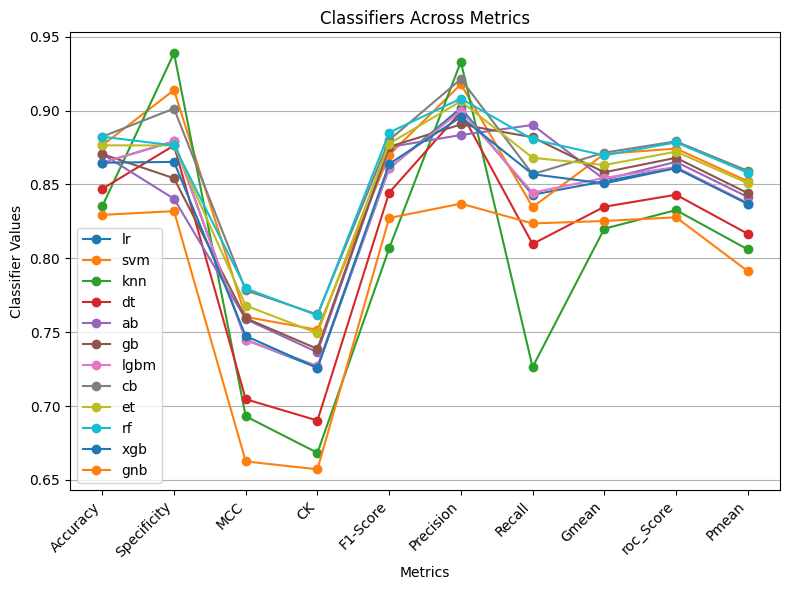

+++++++++++++++++++++++++++++++++++++++++++++End++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++


In [344]:
for i in lt:
    d_x = fdf[i]
    #print(d_x)
    dfy = fdf[["TARGET"]]
    dt=evall(d_x,y,fsname[tin],0)
    odresult.extend(dt)
    dfout=pd.DataFrame(dt,columns=['FName','SMOTE','Classifier','Accuracy','Specificity','MCC','CK','F1-Score','Precision','Recall','Gmean','roc_Score'])
    dfout=favg(dfout)
    evgraph(dfout)
    print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
    
    #with balancing
    
    os = SMOTE()
    Xkm, ykm = os.fit_resample(d_x, y)
    dtkm=evall(Xkm,ykm,fsname[tin],1)
    odresult.extend(dtkm)
    dfkm=pd.DataFrame(dtkm,columns=['FName','SMOTE','Classifier','Accuracy','Specificity','MCC','CK','F1-Score','Precision','Recall','Gmean','roc_Score'])
    dfkm=favg(dfkm)
    evgraph(dfkm)
    print("+++++++++++++++++++++++++++++++++++++++++++++End++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
    tin=tin+1

In [345]:
dF_FS_RES=pd.DataFrame(odresult,columns=['FName','SMOTE','Classifier','Accuracy','Specificity','MCC','CK','F1-Score','Precision','Recall','Gmean','roc_Score'])
dF_FS_RES

,FName,SMOTE,Classifier,Accuracy,Specificity,MCC,CK,F1-Score,Precision,Recall,Gmean,roc_Score
0,LRf,0,lr,0.791818,0.800000,0.499379,0.450212,0.852796,0.956818,0.786111,0.728865,0.793056
1,LRf,0,svm,0.791818,0.166667,0.119815,0.115801,0.877495,0.825732,0.940278,0.213754,0.553472
2,LRf,0,knn,0.790909,0.316667,0.206592,0.203230,0.873137,0.850025,0.905556,0.365829,0.611111
3,LRf,0,dt,0.752727,0.466667,0.240141,0.227091,0.839381,0.870747,0.820833,0.497043,0.643750
4,LRf,0,ab,0.848182,0.466667,0.445866,0.428151,0.907987,0.882096,0.940278,0.549456,0.703472
...,...,...,...,...,...,...,...,...,...,...,...,...
355,majority_features,1,cb,0.882353,0.901389,0.778330,0.762029,0.880059,0.921334,0.856944,0.871527,0.879167
356,majority_features,1,et,0.876471,0.876389,0.768062,0.749311,0.877654,0.906334,0.868056,0.863132,0.872222
357,majority_features,1,rf,0.882353,0.876389,0.779656,0.761364,0.885154,0.908120,0.880556,0.869674,0.878472
358,majority_features,1,xgb,0.864706,0.865278,0.747426,0.725851,0.863912,0.895620,0.856944,0.850683,0.861111


In [346]:
dF_FS_RES=favg(dF_FS_RES)

FName              SMOTE Classifier  Accuracy  Specificity  MCC      CK       F1-Score  Precision  Recall   Gmean    roc_Score  Pmean  
              LRf 0        lr       0.791818  0.800000     0.499379 0.450212 0.852796  0.956818   0.786111 0.728865 0.793056   0.739895
              LRf 0       svm       0.791818  0.166667     0.119815 0.115801 0.877495  0.825732   0.940278 0.213754 0.553472   0.511648
              LRf 0       knn       0.790909  0.316667     0.206592 0.203230 0.873137  0.850025   0.905556 0.365829 0.611111   0.569228
              LRf 0        dt       0.752727  0.466667     0.240141 0.227091 0.839381  0.870747   0.820833 0.497043 0.643750   0.595376
              LRf 0        ab       0.848182  0.466667     0.445866 0.428151 0.907987  0.882096   0.940278 0.549456 0.703472   0.685795
              LRf 0        gb       0.839091  0.466667     0.431162 0.412562 0.901256  0.880588   0.929167 0.577360 0.697917   0.681752
              LRf 0      lgbm       0.847273  0.

In [347]:
dF_FS_RES.to_csv("lung_NEW_project.csv", index=False)
dF_FS_RES

,FName,SMOTE,Classifier,Accuracy,Specificity,MCC,CK,F1-Score,Precision,Recall,Gmean,roc_Score,Pmean
0,LRf,0,lr,0.791818,0.800000,0.499379,0.450212,0.852796,0.956818,0.786111,0.728865,0.793056,0.739895
1,LRf,0,svm,0.791818,0.166667,0.119815,0.115801,0.877495,0.825732,0.940278,0.213754,0.553472,0.511648
2,LRf,0,knn,0.790909,0.316667,0.206592,0.203230,0.873137,0.850025,0.905556,0.365829,0.611111,0.569228
3,LRf,0,dt,0.752727,0.466667,0.240141,0.227091,0.839381,0.870747,0.820833,0.497043,0.643750,0.595376
4,LRf,0,ab,0.848182,0.466667,0.445866,0.428151,0.907987,0.882096,0.940278,0.549456,0.703472,0.685795
...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,majority_features,1,cb,0.882353,0.901389,0.778330,0.762029,0.880059,0.921334,0.856944,0.871527,0.879167,0.859237
356,majority_features,1,et,0.876471,0.876389,0.768062,0.749311,0.877654,0.906334,0.868056,0.863132,0.872222,0.850848
357,majority_features,1,rf,0.882353,0.876389,0.779656,0.761364,0.885154,0.908120,0.880556,0.869674,0.878472,0.857971
358,majority_features,1,xgb,0.864706,0.865278,0.747426,0.725851,0.863912,0.895620,0.856944,0.850683,0.861111,0.836837


In [348]:
maxpmean= dF_FS_RES.loc[dF_FS_RES['Pmean'].idxmax()]

# Display the row with the maximum salary
print("Row with the maximum pmean:")
print(maxpmean)

Row with the maximum pmean:
FName               RFf
SMOTE                 1
Classifier           ab
Accuracy       0.917647
Specificity      0.8875
MCC            0.851265
CK             0.831689
F1-Score       0.925656
Precision      0.928462
Recall         0.940278
Gmean          0.903669
roc_Score      0.913889
Pmean          0.900006
Name: 88, dtype: object


In [349]:
maxroc_Score= dF_FS_RES.loc[dF_FS_RES['roc_Score'].idxmax()]

# Display the row with the maximum 
print("Row with the maximum roc_Score:")
print(maxroc_Score)

Row with the maximum roc_Score:
FName               RFf
SMOTE                 1
Classifier           ab
Accuracy       0.917647
Specificity      0.8875
MCC            0.851265
CK             0.831689
F1-Score       0.925656
Precision      0.928462
Recall         0.940278
Gmean          0.903669
roc_Score      0.913889
Pmean          0.900006
Name: 88, dtype: object


In [350]:
print(dF_FS_RES.index[dF_FS_RES['Pmean'].idxmax()])
ind=dF_FS_RES.index[dF_FS_RES['Pmean'].idxmax()]

88


In [351]:
import joblib
joblib.dump(knn, "lung_model.pkl")

['lung_model.pkl']

In [352]:
import streamlit as st
import joblib
import numpy as np

model = joblib.load("lung_model.pkl")

st.title("Lung Cancer Prediction")

age = st.number_input("Age")
smoking = st.selectbox("Smoking", [0,1])
yellow_fingers = st.selectbox("Yellow Fingers", [0,1])

if st.button("Predict"):
    data = np.array([[age, smoking, yellow_fingers]])
    prediction = model.predict(data)
    st.write("Prediction:", prediction)

2026-03-08 02:56:08.042 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-08 02:56:08.236 
  command:

    streamlit run C:\Users\sulat\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-03-08 02:56:08.237 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-08 02:56:08.238 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-08 02:56:08.238 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-08 02:56:08.239 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-08 02:56:08.239 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-08 02:56:08.240 Thre